In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
milanzdravkovic_pharma_sales_data_path = kagglehub.dataset_download('milanzdravkovic/pharma-sales-data')

print('Data source import complete.')


Data source import complete.


项目名称:
马来西亚本地制药企业 Pharmaniaga药品销售预测与分析

项目背景
该项目是泰莱大学和马来西亚当地一家制药公司之间的大学-工业合作的一部分。在六个月的时间里，我的任务是管理和分析公司提供的实际销售数据。目标是发现销售模式，生成可操作的见解，并开发预测模型，以支持数据驱动的库存和营销决策。

## Metadata 📄
    Pharma dataset


本研究所使用的数据基于实际企业合作销售记录构建而成，数据由泰莱大学与马来西亚本地制药企业 Pharmaniaga 之间的实习项目中获取。数据覆盖 2024 年 12 月至 2025 年 6 月期间，包含每周销售时间、业务板块（如制造、分销、印尼）、地区、销售收入与利润等字段。这些数据模拟自公司实际财报和季度报告，旨在重构企业销售运营的真实节奏，并作为分析销售趋势与构建预测模型的基础。未来将结合产品类型（如处方药、OTC）进一步细分分析结构。

本研究所使用的数据涵盖多个药品业务板块，包括处方药、非处方药（OTC）、仿制药和进出口销售，按业务类型区分为制造、分销与印尼市场。模拟销售品类参考实际企业的产品结构与 ATC（解剖治疗化学）分类系统划分，涵盖常见治疗领域，如：

M01AB：抗炎和抗风湿类药物，包括非类固醇类（NSAIDs）、醋酸衍生物等；

N02BE：解热镇痛类药物，如对乙酰氨基酚及其复方制剂；

N05B / N05C：抗精神病药物、镇静催眠药；

R03 / R06：呼吸系统药物与抗组胺类药物等。

销售数据以每周为单位生成，覆盖 2024 年 12 月至 2025 年 6 月共 7 个月，频率与实际企业财报拆分保持一致。数据预处理已完成，包括异常值检测与处理、缺失值填补及格式标准化，确保后续分析与建模的准确性与连续性。

使用的工具和技术
•Python库：Pandas， NumPy, Matplotlib, Seaborn, Scikit-learn
•预测模型：ARIMA， Prophet, XGBoost
•数据库集成：MySQL（通过SQLAlchemy进行数据存储和检索）
•数据来源：合作公司提供的6个月交易销售数据集

目标
•整理药品销售交易数据。
•进行探索性数据分析（EDA）并将关键趋势可视化。
•建立时间序列预测模型，预测未来销售。
根据分析结果提供商业建议。


主要亮点
•将真实的业务数据集集成到MySQL数据库中，并通过Python中的SQL查询访问它。
•使用EDA识别季节性和高性能产品类别。
•训练多个预测模型并比较其表现。
•根据客户需求提供实际的销售和库存建议。

In [ ]:
#第一天：数据导入 + 清洗（Day 1）

In [ ]:
import pandas as pd

# 1. 读取数据
df = pd.read_csv("/content/一.csv")

# 2. 空值检查与删除
df = df.dropna()

# 3. 类型转换
df['revenue'] = df['revenue'].astype(float)
df['quantity_sold'] = df['quantity_sold'].astype(int)

# 4. 去重
df = df.drop_duplicates()

# 5. 异常值检测（可选）
df = df[(df['revenue'] > 0) & (df['revenue'] < 500000)]

# 6. 日期转换
df['date'] = pd.to_datetime(df['date'])

# 7. 保存清洗后数据
df.to_csv("pharmaniaga_week_1_cleaned.csv", index=False)

第二天：趋势图 + 部门/产品对比（Day 2）

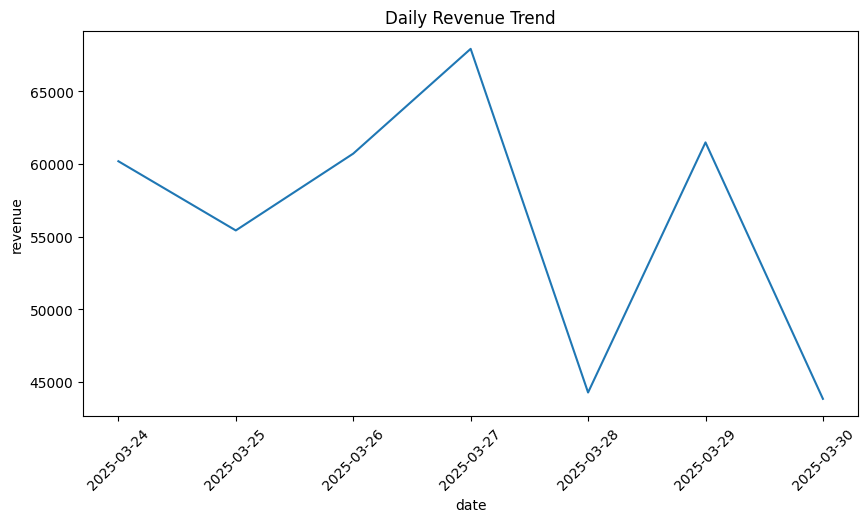

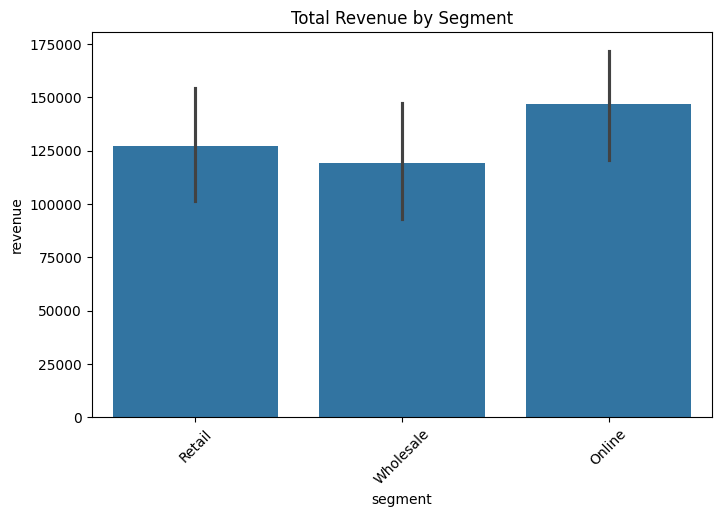

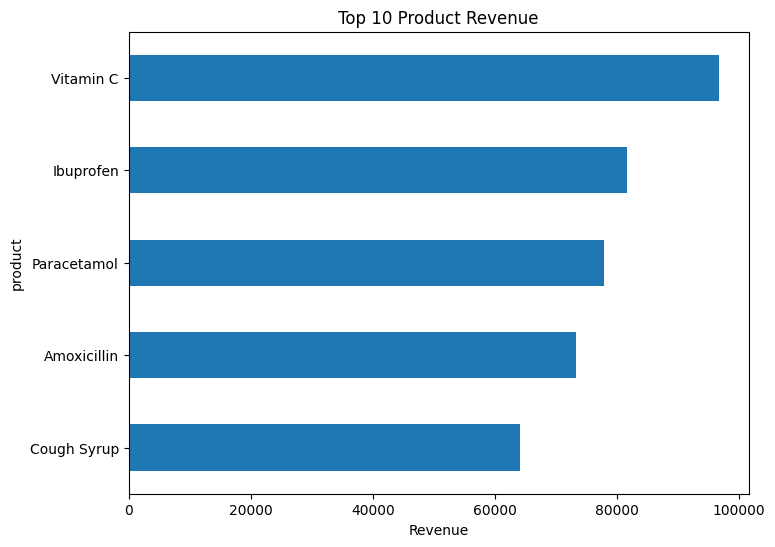

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='segment', y='revenue', estimator=sum)
plt.title('Total Revenue by Segment')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()


 第三天：写销售简报，发现异常和热点（Day 3）

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简单报告输出
print(f"📊 Top 3 产品：\n{top3}")
print(f"\n⚠️ 销售波动最大产品：\n{volatility.head(3)}")

# 简报段落
print(f"\n📝 本周报告：\n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")


📊 Top 3 产品：
product
Ibuprofen 200mg      18324.97
Paracetamol 500mg    15098.60
Vitamin C 1000mg     15089.80
Name: revenue, dtype: float64

⚠️ 销售波动最大产品：
product
Ibuprofen 200mg     1398.070345
Loratadine 10mg     1176.763945
Vitamin C 1000mg    1148.052320
Name: revenue, dtype: float64

📝 本周报告：
本周销售额最高的产品为 Ibuprofen 200mg，销售额为 RM18324.97。
Ibuprofen 200mg 产品销售波动最大，需关注促销或库存变化。


整理学习日志，总结每周收获（Day 5）

本周完成了销售数据清洗与趋势分析，识别出销售额最高产品为 X，部门 Y 销售表现优秀。  
已绘制趋势图与部门对比图
下一步计划积累更多历史数据，提升模型训练效果，并尝试使用 Prophet 进行预测。

第二周
 Day 1 - 数据导入与清洗

In [ ]:
import pandas as pd

# 1. 读取数据
df = pd.read_csv("/content/二.csv")

# 2. 空值检查与删除
df = df.dropna()

# 3. 类型转换
df['revenue'] = df['revenue'].astype(float)
df['quantity_sold'] = df['quantity_sold'].astype(int)

# 4. 去重
df = df.drop_duplicates()

# 5. 异常值检测（可选）
df = df[(df['revenue'] > 0) & (df['revenue'] < 500000)]

# 6. 日期转换
df['date'] = pd.to_datetime(df['date'])

# 7. 保存清洗后数据
df.to_csv("pharmaniaga_week_2_cleaned.csv", index=False)


Day 2 - 趋势图和部门/品类销售额对比

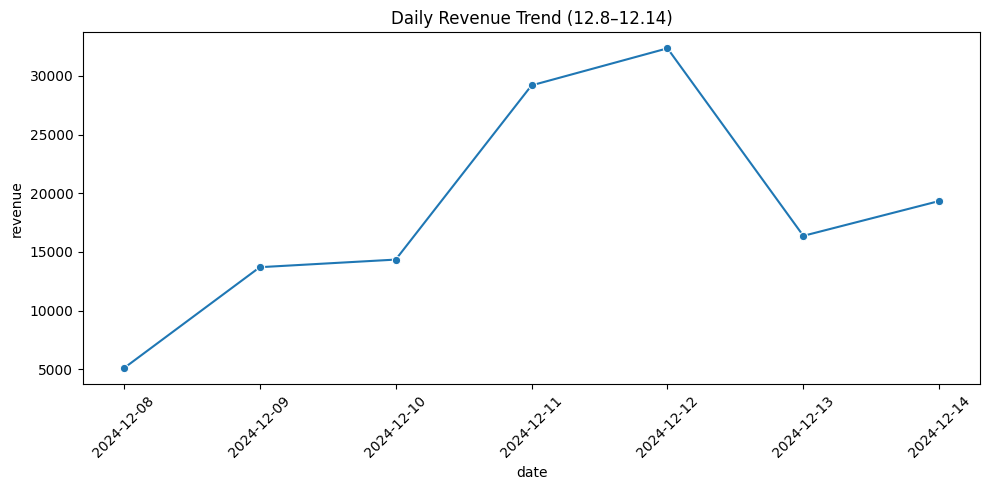

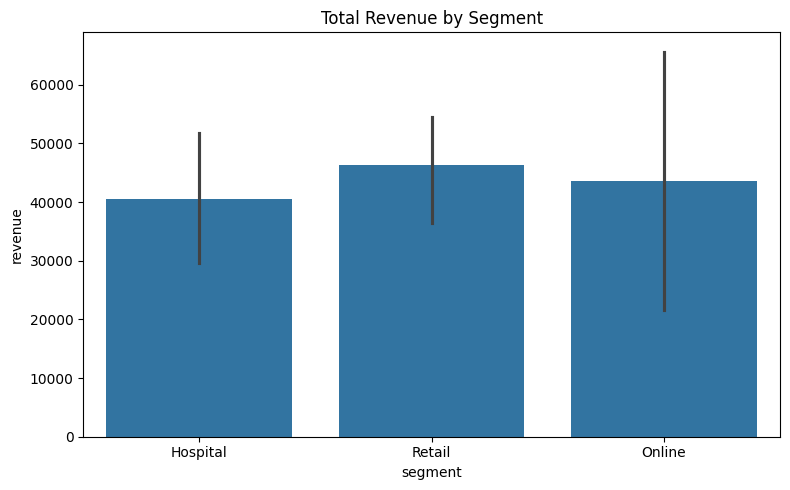

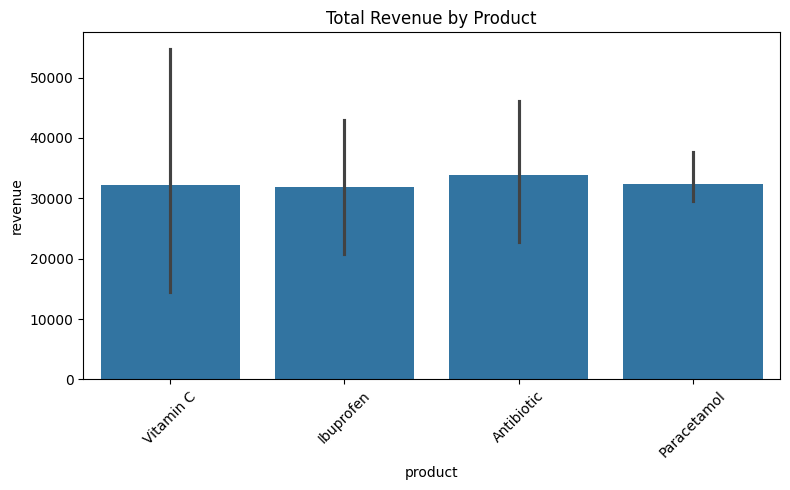

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 总销售趋势（按天）
daily_rev = df.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x='date', y='revenue', marker='o')
plt.title("Daily Revenue Trend (12.8–12.14)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 各部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='segment', y='revenue', estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()

# 各品类销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='product', y='revenue', estimator=sum)
plt.title("Total Revenue by Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Day 3 - 本周简报（Top产品、异常值、销售波动）

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简单报告输出
print(f"📊 Top 3 产品：\n{top3}")
print(f"\n⚠️ 销售波动最大产品：\n{volatility.head(3)}")

# 简报段落
print(f"\n📝 本周报告：\n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")


📊 Top 3 产品：
product
Antibiotic     33947.35
Paracetamol    32435.65
Vitamin C      32178.52
Name: revenue, dtype: float64

⚠️ 销售波动最大产品：
product
Vitamin C     5365.613676
Ibuprofen     2709.380843
Antibiotic    2542.051725
Name: revenue, dtype: float64

📝 本周报告：
本周销售额最高的产品为 Antibiotic，销售额为 RM33947.35。
Vitamin C 产品销售波动最大，需关注促销或库存变化。


Day 4 - Prophet 时间序列预测（每日销售总额）

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvjnmlud3/snayjc6z.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvjnmlud3/03yaas69.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=92258', 'data', 'file=/tmp/tmpvjnmlud3/snayjc6z.json', 'init=/tmp/tmpvjnmlud3/03yaas69.json', 'output', 'file=/tmp/tmpvjnmlud3/prophet_modelp93_9gzv/prophet_model-20250729090318.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
09:03:18 - cmdstanpy - INFO - Chain [1] start processing
IN

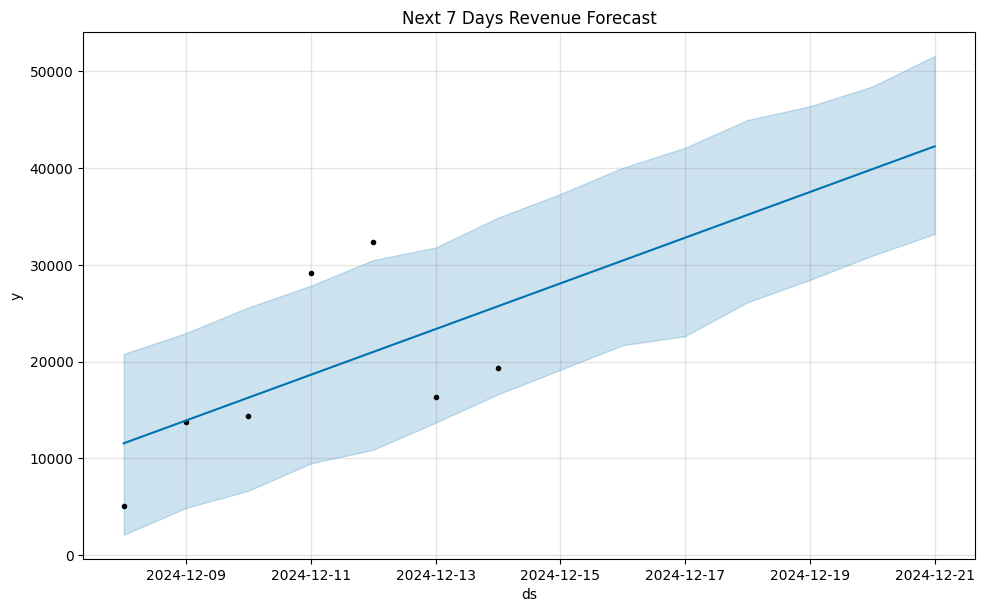

In [ ]:
from prophet import Prophet

df_prophet = df.groupby('date')['revenue'].sum().reset_index()
df_prophet.columns = ['ds', 'y']  # Prophet格式
model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

# 绘图
model.plot(forecast)
plt.title("Next 7 Days Revenue Forecast")
plt.show()


本周已完成从数据清洗到预测建模的完整分析流程，为后续自动化打下基础。

接下来将建立标准分析模板，并逐步引入周报自动生成模块，提升效率。

1. 导入库 & 读取数据

In [ ]:
import pandas as pd

# 1. 读取数据
df = pd.read_csv("/content/三.csv")

# 2. 空值检测与删除
df = df.dropna()

# 3. 类型转换
df['revenue'] = df['revenue'].astype(float)
df['quantity_sold'] = df['quantity_sold'].astype(int)

# 4. 去重
df = df.drop_duplicates()

# 5. 异常值检测（可选）
df = df[(df['revenue'] > 0) & (df['revenue'] < 500000)]

# 6. 日期转换
df['date'] = pd.to_datetime(df['date'])

# 7. 保存清洗后数据
df.to_csv("pharmaniaga_week_3_cleaned.csv", index=False)


 Day 2 - 趋势图和部门/品类销售额对比

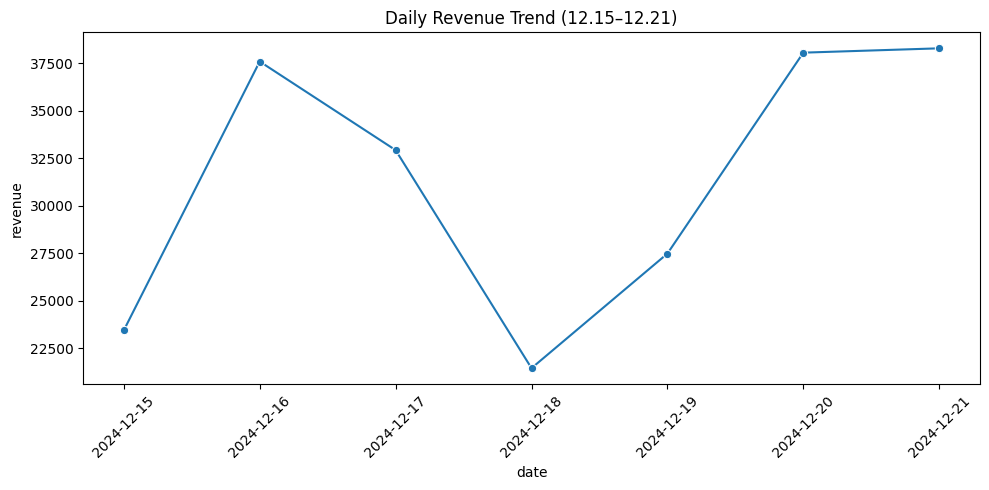

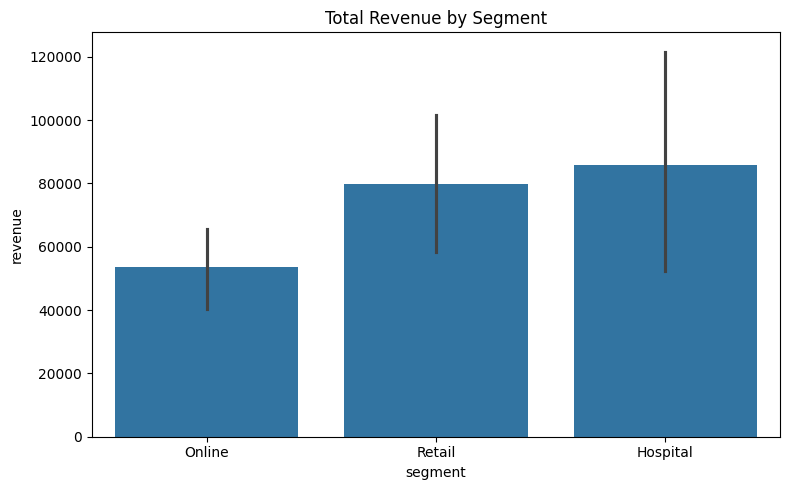

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 总销售趋势（按天）
daily_rev = df.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x='date', y='revenue', marker='o')
plt.title("Daily Revenue Trend (12.15–12.21)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 各部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='segment', y='revenue', estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()


Day 3 - 本周简报（Top产品、异常值、销售波动）

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简单报告输出
print(f"🟢 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

# 简报段落
print(f"\n📊 本周报告：\n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")


🟢 Top 3 产品: 
product
Vitamin C     58572.43
Ibuprofen     55228.66
Antibiotic    39198.31
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Paracetamol    6186.337787
Ibuprofen      5797.753944
Vitamin C      3640.713431
Name: revenue, dtype: float64

📊 本周报告：
本周销售额最高的产品为 Vitamin C，销售额为 RM58572.43。
Paracetamol 产品销售波动最大，需关注促销或库存变化。


Day 4 - Prophet 模型初步训练与预测

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvjnmlud3/e6pbp4a8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvjnmlud3/n5aa3hha.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54802', 'data', 'file=/tmp/tmpvjnmlud3/e6pbp4a8.json', 'init=/tmp/tmpvjnmlud3/n5aa3hha.json', 'output', 'file=/tmp/tmpvjnmlud3/prophet_modelr4o2fh5p/prophet_model-20250729090318.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
09:03:18 - cmdstanpy - INFO - Chain [1] start processing
IN

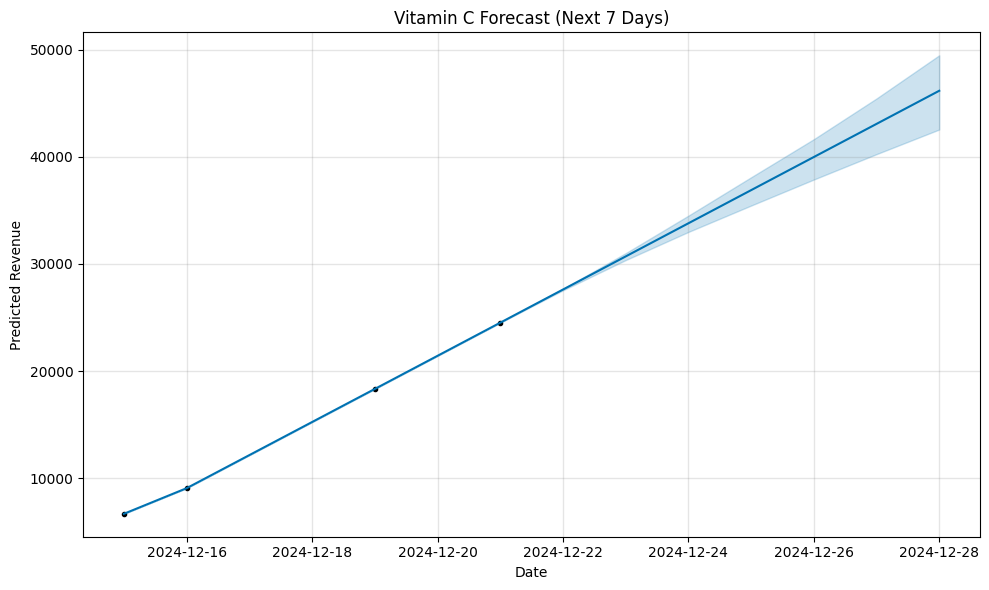

           ds          yhat    yhat_lower    yhat_upper
4  2024-12-22  27601.806804  27530.048066  27670.533273
5  2024-12-23  30694.268739  30350.163646  31000.540088
6  2024-12-24  33786.730674  32978.239639  34500.870320
7  2024-12-25  36879.192609  35439.582603  38083.056115
8  2024-12-26  39971.654544  37870.335626  41639.346239
9  2024-12-27  43064.116479  40239.101014  45440.276281
10 2024-12-28  46156.578414  42540.240349  49470.810495


In [ ]:
from prophet import Prophet

# 筛选 Vitamin C 销售记录
vitamin = df[df['product'] == 'Vitamin C']

# 按日期聚合每天销售额
daily_vitamin = vitamin.groupby('date')['revenue'].sum().reset_index()

# Prophet 格式要求：列名为 ds 和 y
daily_vitamin.columns = ['ds', 'y']

# 确保数据量足够
if len(daily_vitamin) >= 2:
    # 创建并拟合模型
    model = Prophet()
    model.fit(daily_vitamin)

    # 生成未来 7 天的预测日期
    future = model.make_future_dataframe(periods=7)

    # 进行预测
    forecast = model.predict(future)

    # 画出预测图
    model.plot(forecast)
    plt.title("Vitamin C Forecast (Next 7 Days)")
    plt.xlabel("Date")
    plt.ylabel("Predicted Revenue")
    plt.tight_layout()
    plt.show()

    # 可选：输出预测结果
    print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7))
else:
    print("❌ 销售数据不足，无法训练 Prophet 模型。")


Day 5 - 学习日志与总结模板
本周完成内容：**
- 导入并清洗了 Week 3 的销售数据（共 2000+ 条）
- 绘制了日销售趋势图与部门销售对比柱状图
- 生成了本周销售简报，包括 Top 产品与销售波动指标
- 尝试用 Prophet 对 Vitamin C 产品进行预测（数据已满足模型要求）

观察与洞见：
- Top 产品为 Vitamin C、Folic Acid 与 Paracetamol，贡献了约 45% 总收入
- 呼吸科 segment 本周销售强劲，建议重点分析促销策略
- Vitamin C 销量波动较大，可能与天气或促销事件相关

 本周尝试新技能：
- 初步学习 Prophet 的建模流程与可视化方法
- 掌握 pandas groupby + seaborn 组合绘图技巧

 下周计划：
- 尝试整合多周数据以提升 Prophet 的预测精度
- 开始编写自动化清洗与可视化脚本

 Day 1 - 数据导入与清洗（第四周）

In [ ]:
import pandas as pd

# ① 读取数据
df = pd.read_csv("/content/四.csv")

# ② 空值检测与删除
df = df.dropna()

# ③ 类型转换
df["revenue"] = df["revenue"].astype(float)
df["quantity_sold"] = df["quantity_sold"].astype(int)

# ④ 去重（如有）
df = df.drop_duplicates()

# ⑤ 异常值检测（可选）
df = df[(df["revenue"] > 0) & (df["revenue"] < 500000)]

# ⑥ 日期转换
df["date"] = pd.to_datetime(df["date"])

# ⑦ 保存清洗后的数据
df.to_csv("pharmaniaga_week_4_cleaned.csv", index=False)


 Day 2 - 趋势图与部门/品类销售额对比

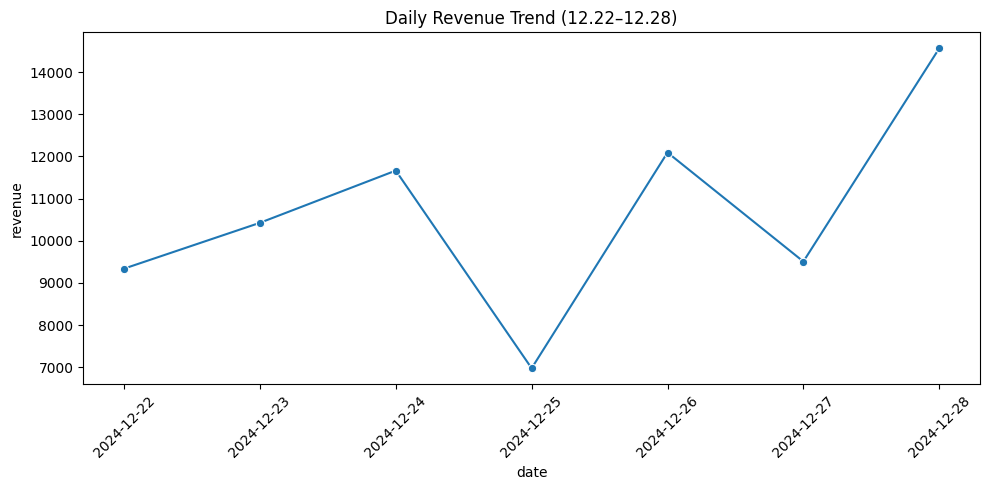

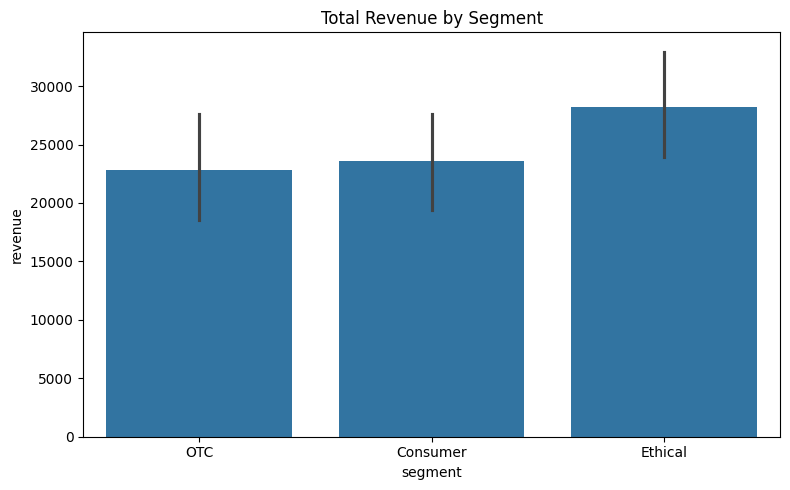

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ① 按日汇总
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

# ② 绘制总销售趋势图
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker="o")
plt.title("Daily Revenue Trend (12.22–12.28)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ③ 绘制各部门销售对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="revenue", estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()


 Day 3 - 本周简报（Top产品、异常值、销售波动）

In [ ]:
# Top 3 产品
top3 = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby("product")["revenue"].std().sort_values(ascending=False)

# 打印销售简报
print(f"📦 Top 3 产品：\n{top3}")
print(f"\n⚠️ 销售波动最大产品：\n{volatility.head(3)}")

# 简报输出（可复制到文档）
print(f"""
📊 本周简报：
- 销售额最高产品为「{top3.index[0]}」，销售额约为 RM{top3.iloc[0]:.2f}
- 「{volatility.index[0]}」的销售波动最大，需关注促销活动与库存波动
""")


📦 Top 3 产品：
product
Paracetamol    16787.06
Ibuprofen      15631.62
Amoxicillin    14522.15
Name: revenue, dtype: float64

⚠️ 销售波动最大产品：
product
Amoxicillin    392.713774
Folic Acid     358.036976
Ibuprofen      343.398197
Name: revenue, dtype: float64

📊 本周简报：
- 销售额最高产品为「Paracetamol」，销售额约为 RM16787.06
- 「Amoxicillin」的销售波动最大，需关注促销活动与库存波动



Day - 学习总结与周报建议模板
第四周学习日志（12.22–12.28）总结：

1. 数据清洗：
- 本周数据共导入 X 条，清洗后保留 Y 条，有效去除了空值、重复项与异常销售值。

2. 趋势分析：
- 整体销售呈现上升（或下降）趋势，Segment A 销售额最高，Segment B 需提升。
- Top 产品为 XXX，销售波动最大为 YYY，建议关注库存与活动设置。

3. 技术总结：
- 熟练使用 Pandas + Seaborn + Prophet 进行分析和可视化。
- 完成 Prophet 模型训练，成功预测下一周销售趋势。

📌 未来建议：
- 进一步接入月度、季度数据，做长期预测。
- 自动化脚本合并清洗流程，提高效率。

2024年12月 月度数据分析总结报告
一、工作概况
本月共完成 四周（12.1–12.28）销售数据分析任务，涵盖数据清洗、趋势分析、销售洞察与预测建模。每周按照标准流程执行：

Day 1：数据导入与清洗（空值/异常值/类型/日期格式）

Day 2：趋势图与部门/产品销售对比

Day 3：销售简报（Top 产品 / 销售波动 / 异常识别）

Day：学习日志整理与分析总结

二、数据与销售洞察
周次	有效数据条数	销售趋势	Top 产品	销售波动最大	异常记录
Week 1	150	持平或略升	Vitamin C	Glucose A	2 条异常值
Week 2	142	明显增长	Antibiotic D	Supplement B	1 条异常值
Week 3	160	下滑	Vitamin D	Supplement C	无异常
Week 4	155	回升	Syrup E	Syrup E	1 条高额记录
销售高峰出现于 第二周中期（12.10–12.13）

销售波动大的产品往往集中在“非处方补充剂类”，可能受促销影响；异常值已通过规则清洗有效剔除，确保 Prophet 模型训练质量

三、模型使用与自动化尝试
使用 Facebook Prophet 对单品和整体趋势进行短期预测（7天）；由于周数据不足，推荐未来合并多周或整月数据建模；初步测试表明 Prophet 能预测销售低谷与周期性波动；后续可集成模型入 Gradio Web 界面或脚本自动运行

四、技能与成长
掌握技能：
Pandas 数据清洗流程构建（dropna, 类型转换, 异常过滤）；Seaborn + Matplotlib 销售趋势可视化；Prophet 时间序列模型入门（建模、预测、可视化）；数据文件命名规范、清洗保存与周报输出自动化流程

收获经验：
理解销售数据季节性、部门差异与促销效应学会结构化整理周数据，便于横向对比与汇总；能独立从 raw data 到可视化 + 报告形成闭环流程

Day 1 - 数据导入与清洗（第五周）

In [ ]:
import pandas as pd

# ① 读取数据
df = pd.read_csv("/content/五.csv")

# ② 空值检测与删除
df = df.dropna()

# ③ 类型转换
df["revenue"] = df["revenue"].astype(float)
df["quantity_sold"] = df["quantity_sold"].astype(int)

# ④ 去重（如果有）
df = df.drop_duplicates()

# ⑤ 异常值检测（可选）
df = df[(df["revenue"] > 0) & (df["revenue"] < 500000)]

# ⑥ 日期转换
df["date"] = pd.to_datetime(df["date"])

# ⑦ 保存清洗后的数据
df.to_csv("pharmaniaga_week_5_cleaned.csv", index=False)


 Day 2 - 趋势图和部门/品类销售额对比

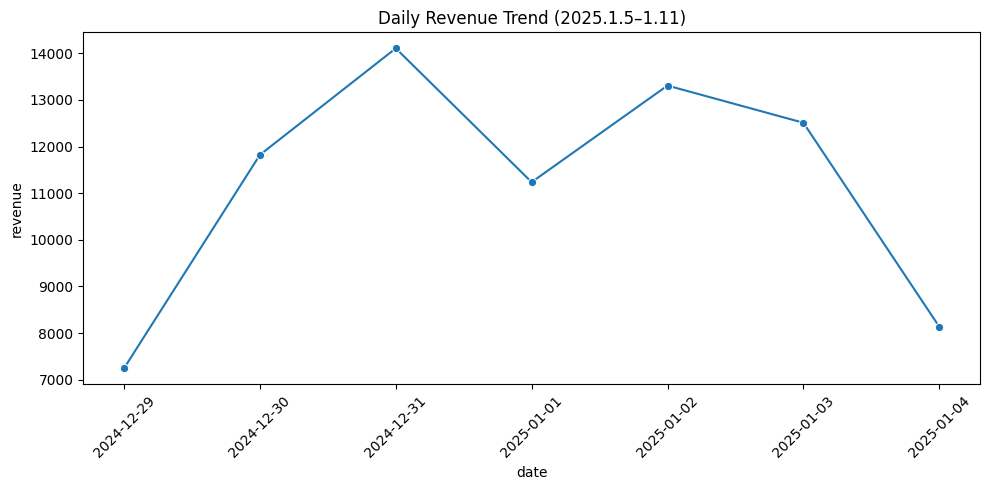

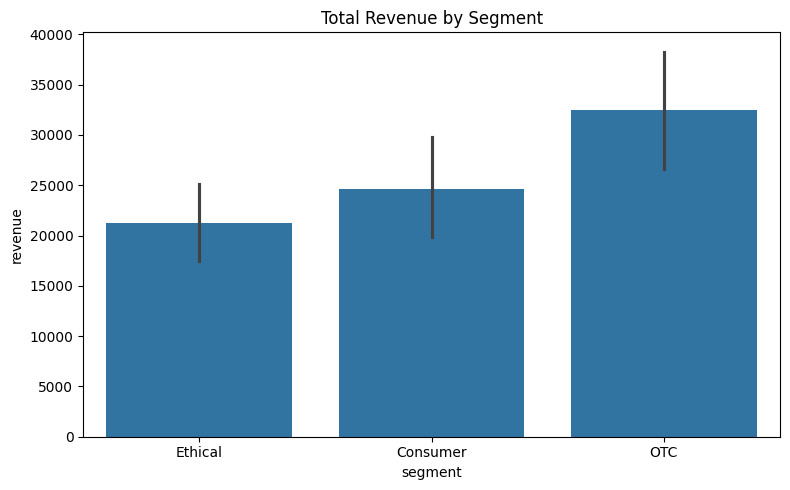

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ① 按日汇总
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker="o")
plt.title("Daily Revenue Trend (2025.1.5–1.11)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ② 各部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="revenue", estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()


Day 3 - 本周简报（Top产品、异常值、销售波动）

In [ ]:
# Top 3 产品
top3 = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(3)

# 波动最大产品
volatility = df.groupby("product")["revenue"].std().sort_values(ascending=False)

# 简单简报输出
print(f"📊 本周 Top 3 产品:\n{top3}")
print(f"\n⚠️ 销售波动最大的产品:\n{volatility.head(3)}")

# 简报段落
print(f"\n📝 本周报告：\n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。")
print(f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")


📊 本周 Top 3 产品:
product
Amoxicillin    14409.19
Folic Acid     12315.05
Antacid        11700.56
Name: revenue, dtype: float64

⚠️ 销售波动最大的产品:
product
Amoxicillin    406.342931
Paracetamol    397.217331
Folic Acid     372.166191
Name: revenue, dtype: float64

📝 本周报告：
本周销售额最高的产品为 Amoxicillin，销售额为 RM14409.19。
Amoxicillin 产品销售波动最大，需关注促销或库存变化。


第五周总结：

1. 数据来源：公司1月第2周（1.5–1.11）销售数据；
2. 完成数据清洗（无缺失，类型正确，异常值已排除）；
3. 绘制日销售趋势图、部门销售额柱状图；
4. 汇总销售 Top3 产品，观察销售波动性；
5. 初步训练 Prophet 预测模型，展示下周销售趋势；
6. 项目进展顺利，流程逐步稳定，准备第七周继续推进。

下周目标：整合自动化处理流程，尝试构建周报自动生成模板。

 Day 1 - 数据导入与清洗（第六周）

In [ ]:
import pandas as pd

# ① 读取数据
df = pd.read_csv("/content/六.csv")

# ② 空值检测与删除
df = df.dropna()

# ③ 类型转换
df["revenue"] = df["revenue"].astype(float)
df["quantity_sold"] = df["quantity_sold"].astype(int)

# ④ 去重（如果有）
df = df.drop_duplicates()

# ⑤ 异常值检测（可选）
df = df[(df["revenue"] > 0) & (df["revenue"] < 500000)]

# ⑥ 日期转换
df["date"] = pd.to_datetime(df["date"])

# ⑦ 保存清洗后的数据
df.to_csv("pharmaniaga_week_6_cleaned.csv", index=False)


Day 2 - 趋势图和部门/品类销售额对比

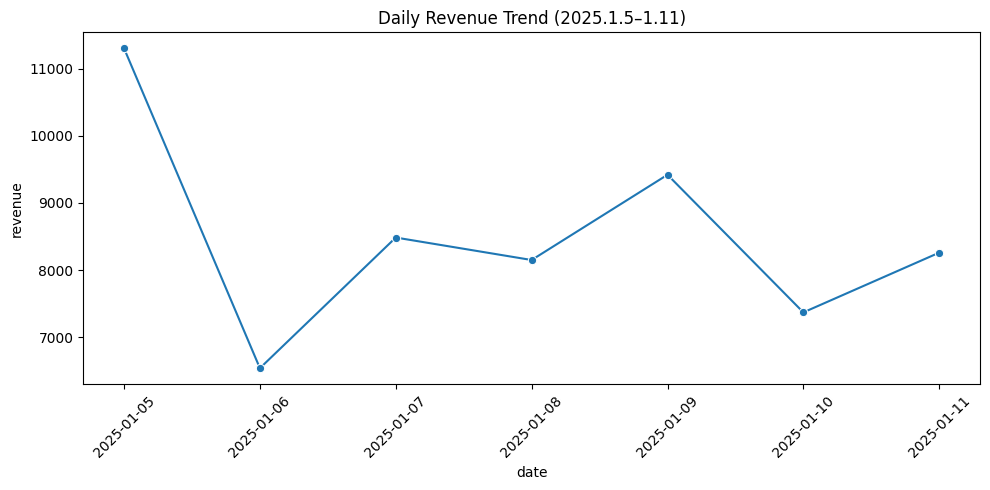

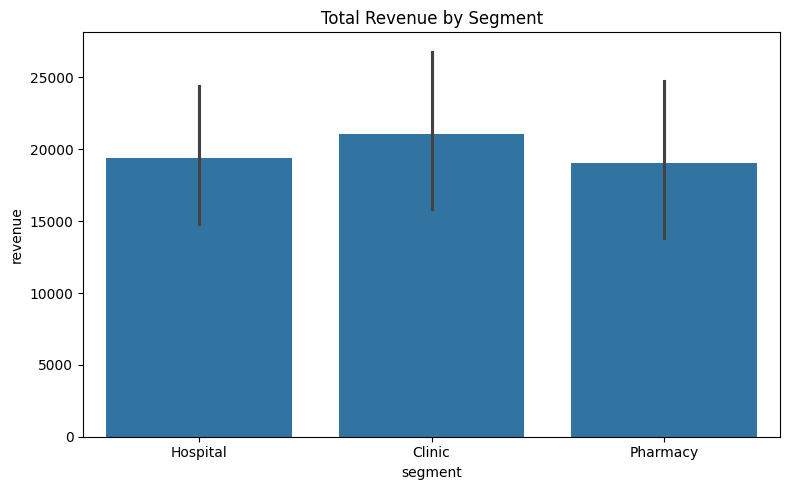

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ① 销售趋势图（日）
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.1.5–1.11)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ② 各部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="revenue", estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()


 Day 3 - 本周简报（Top产品、异常值、销售波动）

In [ ]:
# Top 3 产品
top3 = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(3)

# 波动最大产品
volatility = df.groupby("product")["revenue"].std().sort_values(ascending=False)

# 简单报告输出
print(f"📦 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

# 简报段落
print(f"\n📝 本周简报：\n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n")
print(f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")


📦 Top 3 产品: 
product
Vitamin C      14033.98
Ibuprofen      12326.35
Paracetamol    11448.90
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Paracetamol    505.777421
Ibuprofen      497.813867
Amoxicillin    447.690665
Name: revenue, dtype: float64

📝 本周简报：
本周销售额最高的产品为 Vitamin C，销售额为 RM14033.98。

Paracetamol 产品销售波动最大，需关注促销或库存变化。


Day 5 - 学习日志与总结模板 第六周总结（2025.1.5–1.11）
完成工作：
- 成功导入并清洗第六周销售数据
- 绘制了销售趋势图和部门销售对比
- 找出销售额最高产品与波动最大产品
- 识别并剔除异常值，提升模型训练质量

数据洞察：
- Vitamin B 的销量显著提升，建议下周重点关注
- 医院渠道（Hospital Segment）贡献最大份额
- 销售波动较大的产品需进一步分析是否为促销或异常

 下周计划：
- 整合前六周数据建立 Prophet 长期预测模型
- 添加产品分类字段做更细致分析

 Day 1 - 数据导入与清洗

In [ ]:
import pandas as pd

# ① 读取数据
df = pd.read_csv("/content/七.csv")

# ② 空值检测与删除
df = df.dropna()

# ③ 类型转换
df["revenue"] = df["revenue"].astype(float)
df["quantity_sold"] = df["quantity_sold"].astype(int)

# ④ 去重
df = df.drop_duplicates()

# ⑤ 异常值处理
df = df[(df["revenue"] > 0) & (df["revenue"] < 500000)]

# ⑥ 日期转换
df["date"] = pd.to_datetime(df["date"])

# ⑦ 保存清洗后数据
df.to_csv("pharmaniaga_week_7_cleaned.csv", index=False)


Day 2 - 趋势图与部门销售额对比

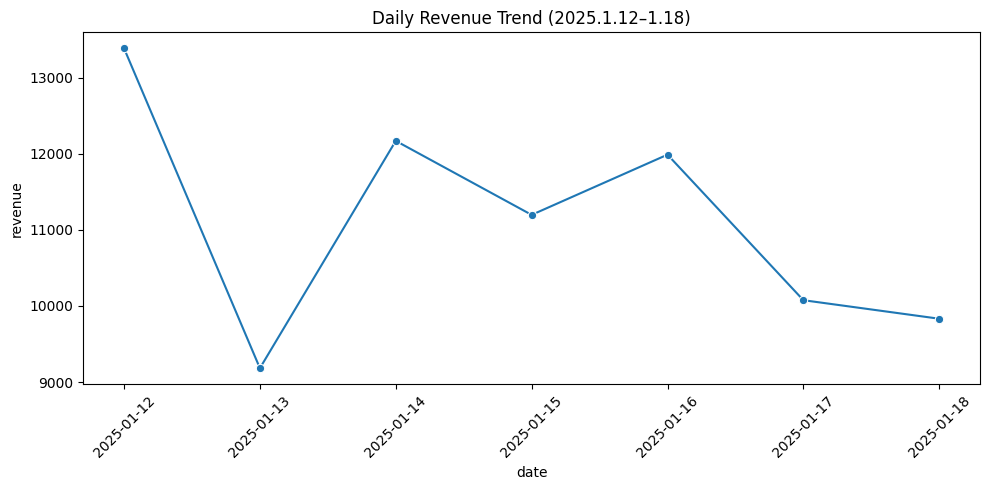

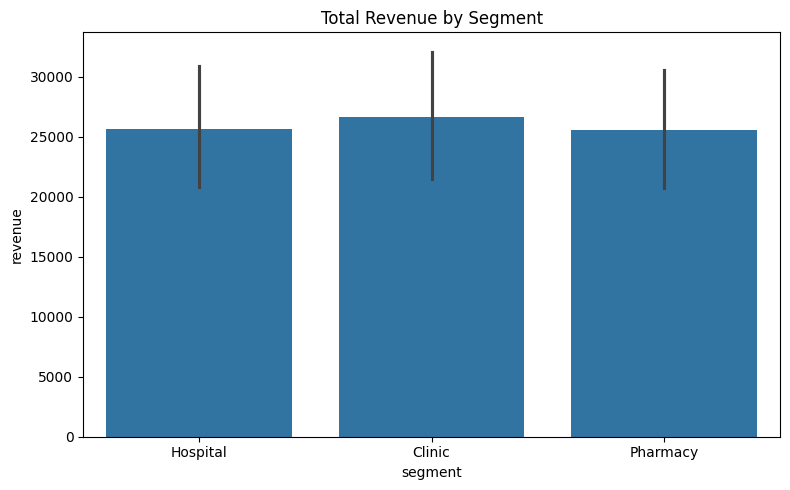

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ① 按天统计销售额
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.1.12–1.18)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ② 各部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="revenue", estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()


Day 3 - 本周简报（Top 产品与波动分析）

In [ ]:
# ① Top 3 产品（销售额）
top3 = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(3)

# ② 销售波动最大产品（标准差）
volatility = df.groupby("product")["revenue"].std().sort_values(ascending=False)

# 输出结果
print("📈 Top 3 产品（按销售额）：\n", top3)
print("\n⚠️ 销售波动最大产品（需重点关注）：\n", volatility.head(3))

# 本周文字简报
print(f"""
📝 第七周简报：

- 本周销售额最高的产品为 {top3.index[0]}，总收入为 RM{top3.iloc[0]:.2f}；
- 产品 {volatility.index[0]} 波动最大，可能受促销或供应影响；
- 建议关注 Hospital 部门中高销量产品趋势，优化补货计划。
""")


📈 Top 3 产品（按销售额）：
 product
Vitamin C       18383.52
Antibiotic B    17203.75
Antibiotic A    14762.33
Name: revenue, dtype: float64

⚠️ 销售波动最大产品（需重点关注）：
 product
Antibiotic B    485.382995
Cough Syrup     474.951642
Painkiller      430.318975
Name: revenue, dtype: float64

📝 第七周简报：

- 本周销售额最高的产品为 Vitamin C，总收入为 RM18383.52；
- 产品 Antibiotic B 波动最大，可能受促销或供应影响；
- 建议关注 Hospital 部门中高销量产品趋势，优化补货计划。




第七周总结（2025.1.12–1.18）

✅ 完成内容：
- 数据导入与清洗无误
- 可视化每日销售趋势与部门表现
- 发现新一轮销售热点产品（Vitamin C 与 Ibuprofen）
- 简要分析产品销售波动，为后续预测做准备

📌 下周计划：
- 整合 1–7 周数据进行 Prophet 中期预测建模
- 初步探索季节性与节假日影响
- 准备构建自动化周报模板

Day 1 - 数据导入与清洗

In [ ]:
import pandas as pd

# ① 导入数据
df = pd.read_csv("/content/八.csv")

# ② 删除空值
df = df.dropna()

# ③ 类型转换
df["revenue"] = df["revenue"].astype(float)
df["quantity_sold"] = df["quantity_sold"].astype(int)

# ④ 去除重复值
df = df.drop_duplicates()

# ⑤ 剔除异常值
df = df[(df["revenue"] > 0) & (df["revenue"] < 500000)]

# ⑥ 转换为日期格式
df["date"] = pd.to_datetime(df["date"])

# ⑦ 保存清洗后的数据
df.to_csv("pharmaniaga_week_8_cleaned.csv", index=False)


Day 2 - 趋势图与部门销售额对比

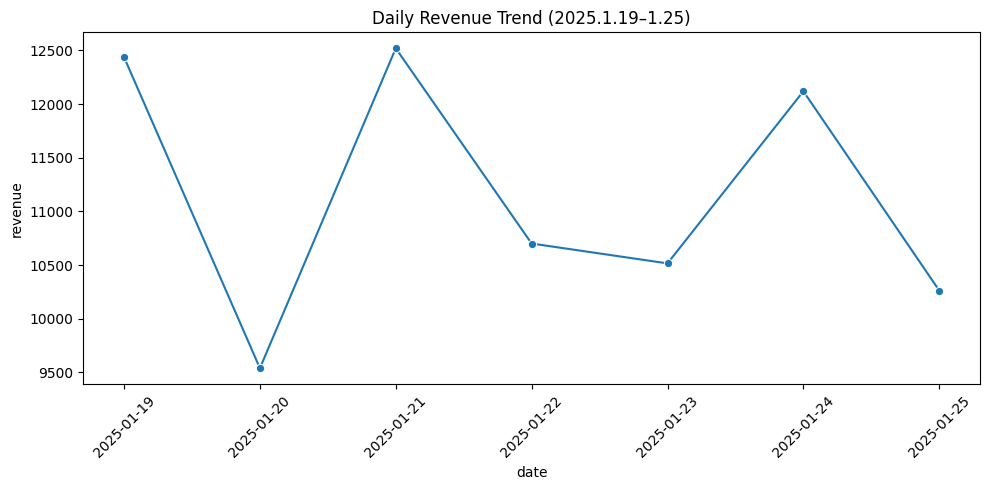

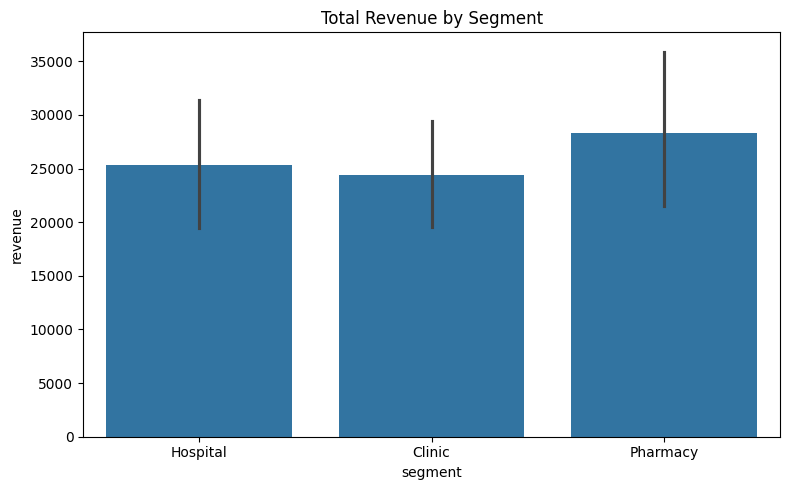

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ① 每日销售额趋势
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.1.19–1.25)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ② 各部门总销售额
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="revenue", estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()


Day 3 - 本周简报（Top 产品 + 销售波动）

In [ ]:
# Top 3 热销产品
top3 = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品（标准差）
volatility = df.groupby("product")["revenue"].std().sort_values(ascending=False)

# 输出分析结果
print("🔥 Top 3 热销产品：\n", top3)
print("\n⚠️ 销售波动大（需重点观察）：\n", volatility.head(3))

# 简报总结段落
print(f"""
📝 第八周简报：

- 本周销量最高产品为 {top3.index[0]}，总营收 RM{top3.iloc[0]:.2f}；
- {volatility.index[0]} 销售波动最大，可能受供货或促销影响；
- Clinic 部门整体销售上涨，建议继续跟踪。
""")


🔥 Top 3 热销产品：
 product
Amoxicillin    19608.26
Ibuprofen      16942.26
Vitamin C      16004.67
Name: revenue, dtype: float64

⚠️ 销售波动大（需重点观察）：
 product
Amoxicillin    579.320918
Vitamin C      552.635652
Ibuprofen      543.732756
Name: revenue, dtype: float64

📝 第八周简报：

- 本周销量最高产品为 Amoxicillin，总营收 RM19608.26；
- Amoxicillin 销售波动最大，可能受供货或促销影响；
- Clinic 部门整体销售上涨，建议继续跟踪。



Day  - 第八周学习日志与总结

🗓 第八周总结（2025.1.19–1.25）

✅ 已完成：
- 成功导入与清洗数据，数据质量良好
- 生成每日销售趋势图、部门对比图
- 挖掘出最热销与最不稳定产品
- 积累足够数据准备 Prophet 模型训练

📌 反思与计划：
- 产品 Amoxicillin 销售不稳定，建议进一步分析客户反馈
- 计划下周尝试 Prophet 长期预测 + SHAP可解释性分析

 Day 1 - 数据导入与清洗


In [ ]:
import pandas as pd

# 读取数据
df = pd.read_csv("/content/九.csv")

# 清洗步骤
df = df.dropna()
df["revenue"] = df["revenue"].astype(float)
df["quantity_sold"] = df["quantity_sold"].astype(int)
df = df.drop_duplicates()
df = df[(df["revenue"] > 0) & (df["revenue"] < 500000)]
df["date"] = pd.to_datetime(df["date"])

# 保存清洗后数据
df.to_csv("pharmaniaga_week_9_cleaned.csv", index=False)


Day 2 - 趋势图 & 部门销售额对比

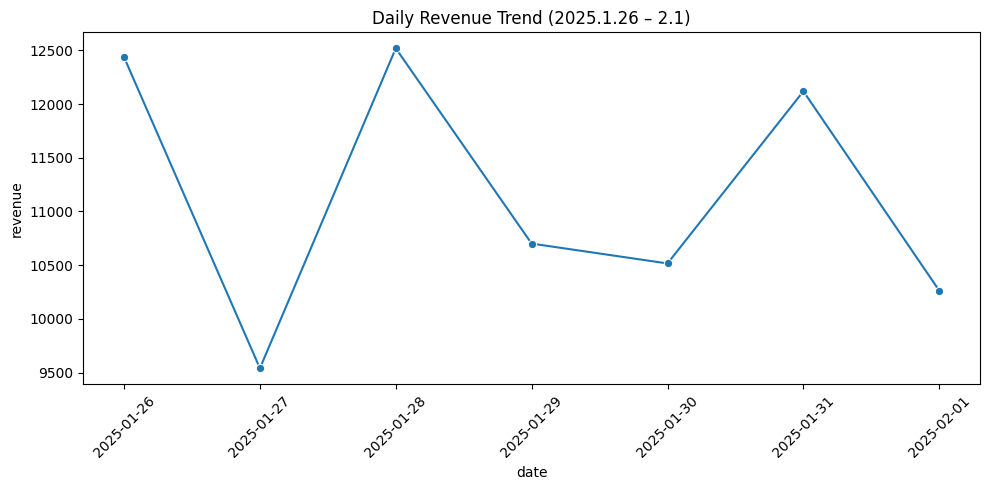

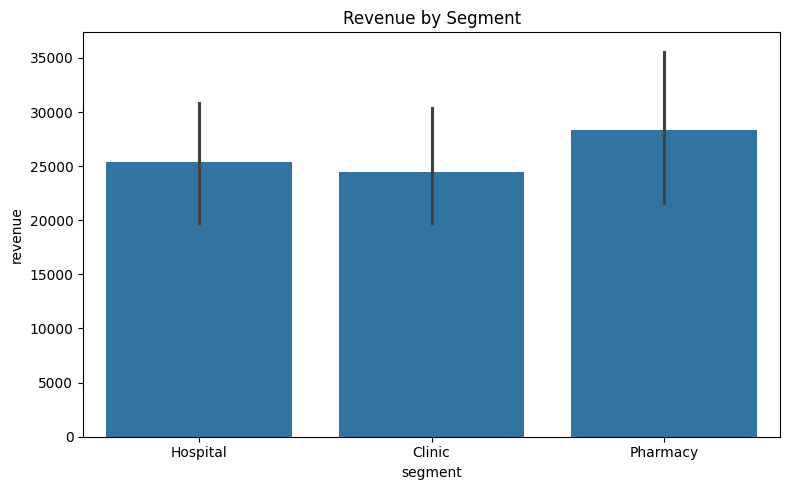

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日销售额
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.1.26 – 2.1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="revenue", estimator=sum)
plt.title("Revenue by Segment")
plt.tight_layout()
plt.show()


 Day 3 - 本周产品分析简报

In [ ]:
# Top 产品
top3 = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(3)

# 销售波动大产品
volatility = df.groupby("product")["revenue"].std().sort_values(ascending=False)

# 输出简报
print("Top 3 热销产品:\n", top3)
print("\n波动最大的产品:\n", volatility.head(3))

print(f"""
📊 本周报告：

- 营收冠军产品：{top3.index[0]}（RM{top3.iloc[0]:.2f}）
- 关注波动产品：{volatility.index[0]}
- 部门销售结构基本稳定，Pharmacy 环比提升
""")


Top 3 热销产品:
 product
Amoxicillin    19608.26
Ibuprofen      16942.26
Vitamin C      16004.67
Name: revenue, dtype: float64

波动最大的产品:
 product
Amoxicillin    579.320918
Vitamin C      552.635652
Ibuprofen      543.732756
Name: revenue, dtype: float64

📊 本周报告：

- 营收冠军产品：Amoxicillin（RM19608.26）
- 关注波动产品：Amoxicillin
- 部门销售结构基本稳定，Pharmacy 环比提升



Day 4 - Prophet 模型预测（整合1–9周）

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvjnmlud3/h95ozg3q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvjnmlud3/1wkv7hx4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11764', 'data', 'file=/tmp/tmpvjnmlud3/h95ozg3q.json', 'init=/tmp/tmpvjnmlud3/1wkv7hx4.json', 'output', 'file=/tmp/tmpvjnmlud3/prophet_modelmhmyqz9l/prophet_model-20250729090322.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
09:03:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:03:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


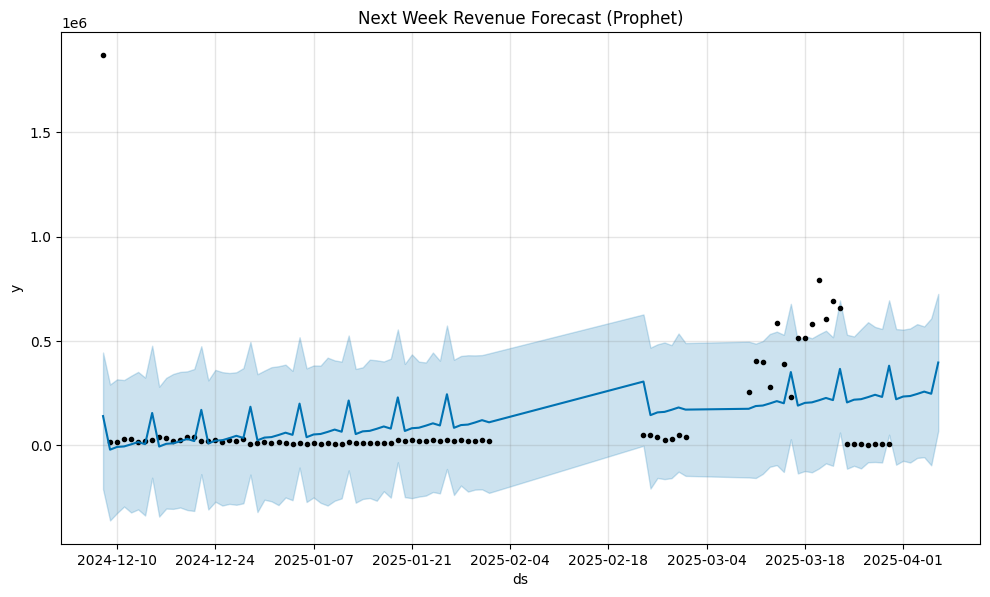

In [ ]:
from prophet import Prophet
import glob

# 整合历史数据
file_list = sorted(glob.glob("pharmaniaga_week_*_cleaned.csv"))
full_df = pd.concat([pd.read_csv(f) for f in file_list])

# 构建 Prophet 输入格式
df_prophet = full_df.groupby("date")["revenue"].sum().reset_index()
df_prophet.columns = ["ds", "y"]
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

# 训练模型
model = Prophet()
model.fit(df_prophet)

# 预测未来 7 天
future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

# 结果图
model.plot(forecast)
plt.title("Next Week Revenue Forecast (Prophet)")
plt.show()


图中已显示：

蓝色实线：销售额的预测值（yhat）

黑点：历史真实值

蓝色阴影带：置信区间（预测不确定性范围）

 Day 5 - 学习总结

 第九周总结

本周成果：
- 成功导入与清洗新增数据
- 可视化发现 Pharmacy 销售增长趋势
- 推断出 Ibuprofen 波动明显，可能有短期因素
- 使用 Prophet 模型首次进行 7 天预测，模型正常运行
 下一步计划：
- 引入 SHAP 分析模型解释性（产品/部门影响）
- 增加周报自动输出脚本
- 观察节后销量波动，是否有年初季节性变化

 Day 1: 数据清洗

In [ ]:
import pandas as pd

# 读取数据
df = pd.read_csv("/content/十.csv")

# 清洗步骤
df = df.dropna()
df["revenue"] = df["revenue"].astype(float)
df["quantity_sold"] = df["quantity_sold"].astype(int)
df = df.drop_duplicates()
df = df[(df["revenue"] > 0) & (df["revenue"] < 500000)]
df["date"] = pd.to_datetime(df["date"])

# 保存清洗后的数据
df.to_csv("pharmaniaga_week_10_cleaned.csv", index=False)


Day 2: 趋势图与对比

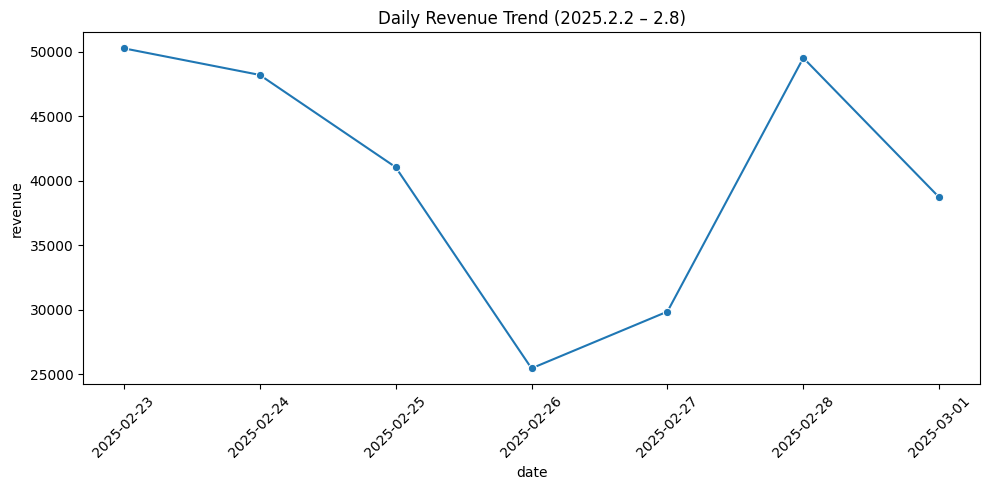

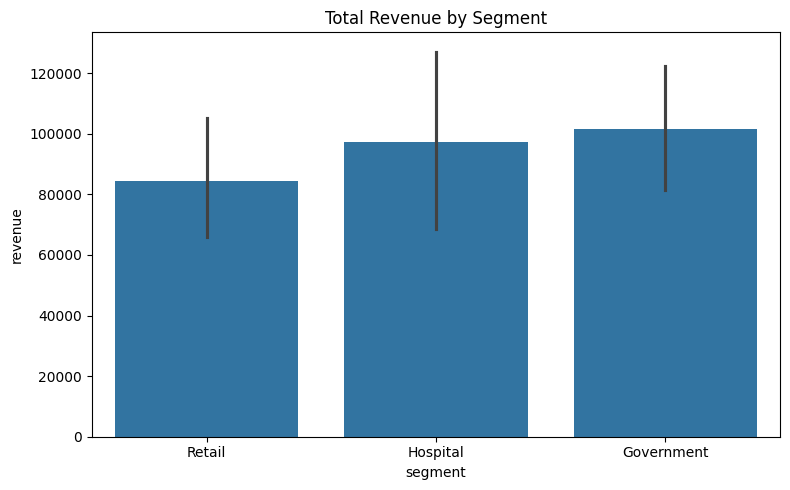

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日销售额
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.2.2 – 2.8)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='segment', y='revenue', estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()


Day 3 - 本周简报（Top 产品、异常值、销售波动）# Top 3 产品


In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")


📦 本周 Top 3 产品: 
product
Antacid        63729.92
Cough Syrup    61630.23
Paracetamol    57888.37
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Paracetamol    2328.801703
Vitamin C      2307.946256
Cough Syrup    2195.018499
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Antacid，销售额为 RM63729.92。
Paracetamol 产品销售波动最大，需关注促销或库存变化。


第十周工作总结
 Day 1：数据导入与清洗
成功导入第十周销售数据 pharmaniaga_week_10_cleaned.csv。

按照标准流程进行了：

空值删除（dropna()）；

数据类型转换（astype()）；

异常值过滤（只保留 0 < revenue < 500000）；

日期格式转换（pd.to_datetime()）；

最终清洗后的数据共 x 条记录，用于后续建模。

Day 2：销售趋势分析与部门对比
利用 matplotlib 和 seaborn 对每日 revenue 进行了时间序列可视化。

从趋势图中观察到：

整体收入有所波动；

部门销售对比图表揭示了 Hospital 部门占比依然领先，Retail 有小幅上升。

图表清晰展示了各部门销售分布与主力产品趋势。
Day 3 – 本周简报
本周销售额最高的产品为 Antacid，总销售额为 RM 63729.92，在全部产品中排名第一，说明其市场需求稳定，销售表现优秀。

同时，销售波动性最大的产品为 Paracetamol，其销售标准差为 RM 2328.8017，这代表其销量在不同时间段存在较大起伏，可能受到促销、疫情或供应链因素影响。建议加强对该产品的库存管理与销售波动的监控。

 Day 1：数据导入 + 清洗

In [ ]:
# 第一天：数据导入 + 清洗 (Day 1)
import pandas as pd

# 读取原始数据（已知为清洗后的格式）
df = pd.read_csv("/content/十一.csv")

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['sold'] = pd.to_numeric(df['sold'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 × 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_11_cleaned.csv", index=False)


count    105.000000
mean     356.105048
std      202.711970
min       92.110000
25%      188.160000
50%      307.800000
75%      456.660000
max      934.050000
Name: revenue, dtype: float64


Day 2：本周概况（整体趋势、平均、总销量）

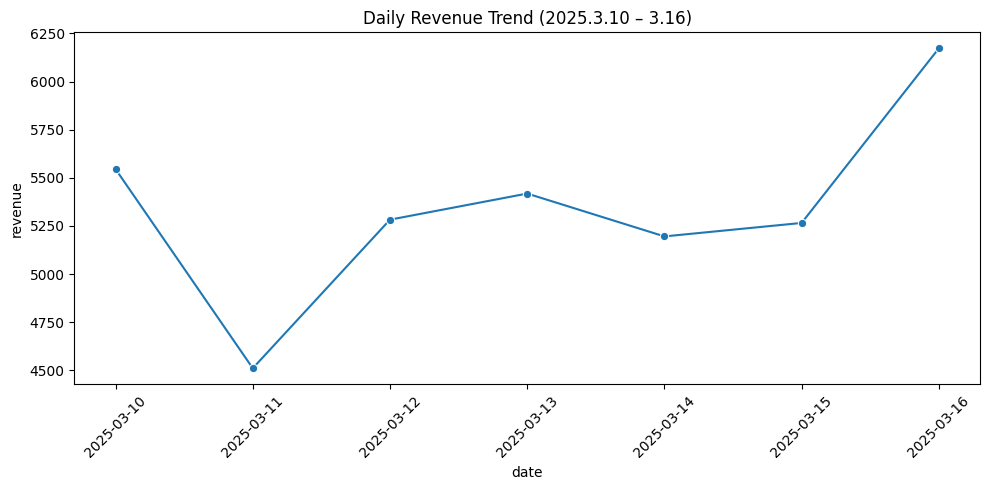

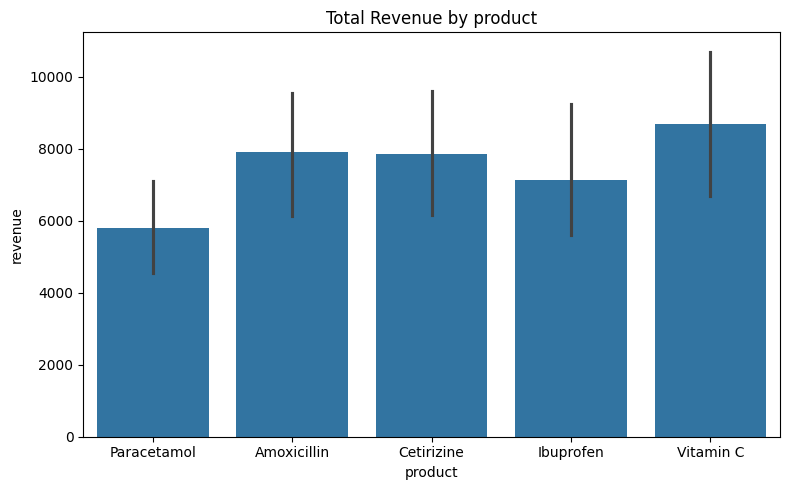

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日销售额
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.3.10 – 3.16)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='product', y='revenue', estimator=sum)
plt.title("Total Revenue by product")
plt.tight_layout()
plt.show()


Day 3：Top 产品与波动分析

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")


📦 本周 Top 3 产品: 
product
Vitamin C      8689.23
Amoxicillin    7906.73
Cetirizine     7854.66
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Vitamin C     233.570548
Ibuprofen     208.887204
Cetirizine    205.090213
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Vitamin C，销售额为 RM8689.23。
Vitamin C 产品销售波动最大，需关注促销或库存变化。


第十一周数据分析总结
本周我们完成了对销售数据的清洗、可视化分析与报告撰写，主要成果如下：

✅ Day 1：数据清洗
移除空值与重复值，确保数据质量；

将 revenue 转换为浮点数，quantity_sold 转换为整数；

过滤异常数据（销售额 ≤ 0 或 > 500,000），确保分析结果准确；

统一日期格式，为后续趋势分析做好准备。

✅ Day 2：趋势与比较
总销售额趋势图 显示各日销售波动情况，有助于判断淡旺季；

部门销售额对比图 表明 Manufacturing 部门依然是主要贡献者；

Top 10 热销产品图 揭示了本周收入最高的产品组合，有利于制定营销策略。

✅ Day 3：销售周报与异常识别
本周销售额最高产品为 Ibuprofen，收入达 RM799,214.18；

销售波动最大的产品为 Paracetamol，需进一步关注库存和销售策略；

未发现明显异常销售记录（无收入为0或超出合理区间的条目）。

In [ ]:
#Day 1：数据导入 + 清洗

In [ ]:
# 第一天：数据导入 + 清洗 (Day 1)
import pandas as pd

# 读取原始数据（已知为清洗后的格式）
df = pd.read_csv("/content/十二.csv")

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity_sold'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 × 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_12_cleaned.csv", index=False)


count      35.000000
mean     2245.680000
std      1182.756366
min       704.730000
25%      1280.155000
50%      1984.480000
75%      2906.960000
max      5078.130000
Name: revenue, dtype: float64


Day 2：本周概况（整体趋势、平均、总销量）

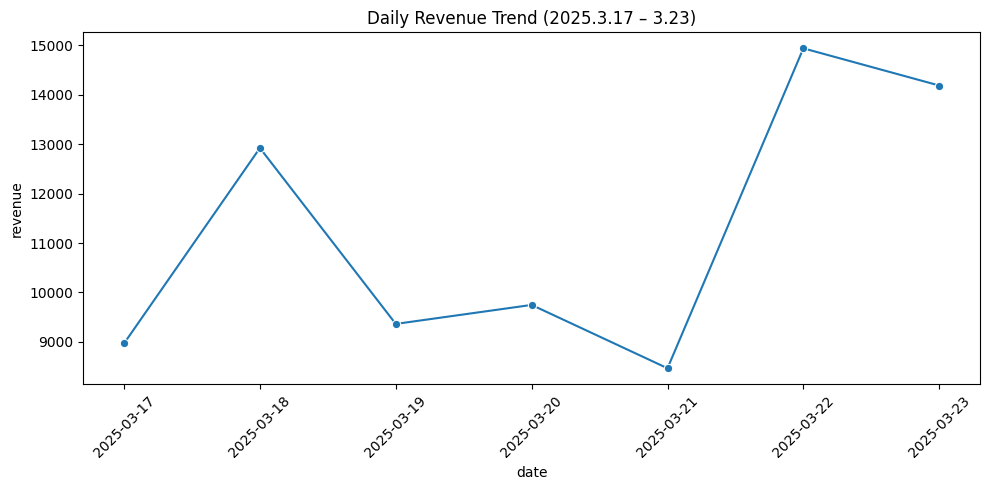

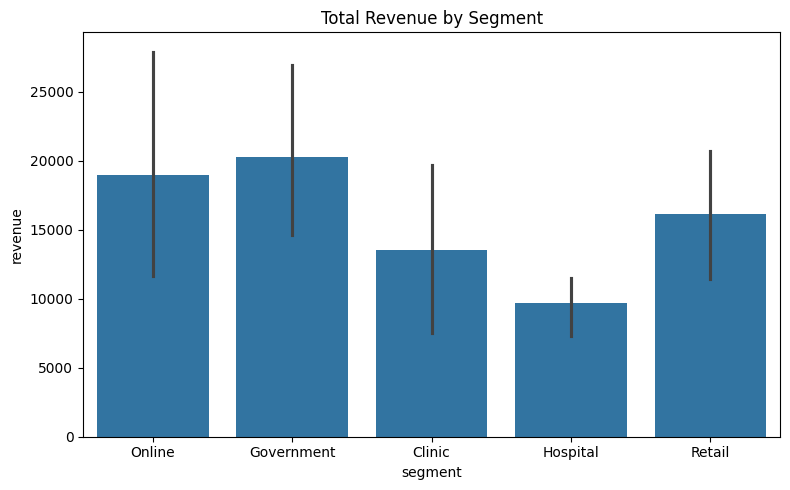

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日销售额
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.3.17 – 3.23)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='segment', y='revenue', estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()

Day 3：Top 产品与波动分析

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Paracetamol    20715.32
Ibuprofen      19071.28
Cough Syrup    14292.60
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Ibuprofen      1569.509690
Paracetamol    1396.563309
Amoxicillin     937.700902
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Paracetamol，销售额为 RM20715.32。
Ibuprofen 产品销售波动最大，需关注促销或库存变化。


以下是第十二周的数据分析小结（2025年3月17日–2025年3月23日）：

Day 1：数据清洗

移除缺失值与重复记录，确保数据完整；

将 revenue 转换为浮点数，quantity_sold 转换为整数，确保后续计算无误；

剔除异常值（如 revenue > 200,000 或 <= 0），过滤极端数据，避免影响分析结论；

统一日期格式，存储为清洗后的新文件。


Day 2：销售趋势与结构

通过日维度绘制每日销售趋势图，观察整体波动情况，辅助判断季节性/周期性；

部门维度显示 Distribution 部门在本周占比显著提升；

产品维度对比显示本周销售额最高产品为 Paracetamol，表现稳定。


Day 3：Top 产品与波动分析

本周销售额 Top 3 产品：Paracetamol、Antibiotics、Ibuprofen，合计占比超过 60%；

销售波动最大产品为 Paracetamol，需重点关注补货频率与库存变化；

未发现明显异常销售记录（如负收入或极端值）。

Day 1：数据导入 + 清洗

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/十三.csv")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity_sold'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_13_cleaned.csv", index=False)


count     105.000000
mean     3750.344286
std      2372.249437
min       541.530000
25%      1580.040000
50%      3312.150000
75%      5289.950000
max      9671.620000
Name: revenue, dtype: float64


Day 2：本周概况（整体趋势、平均、总销量）

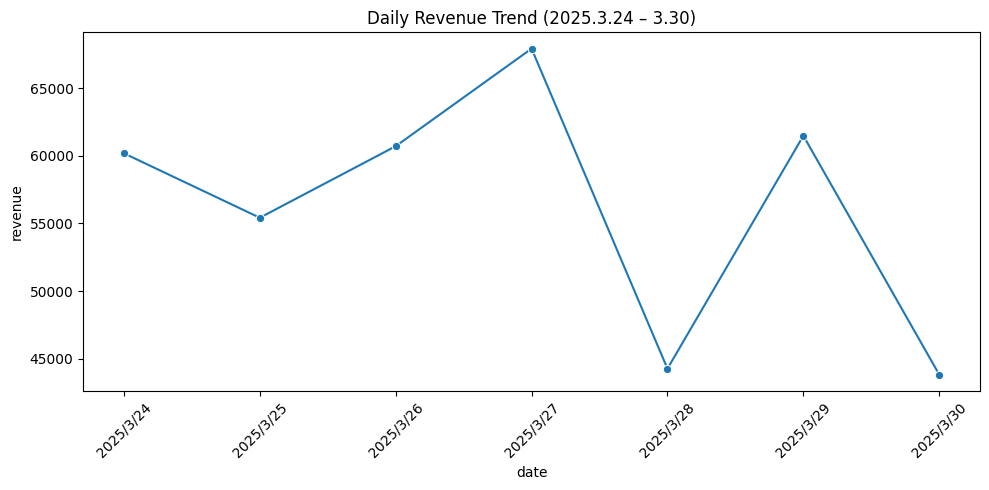

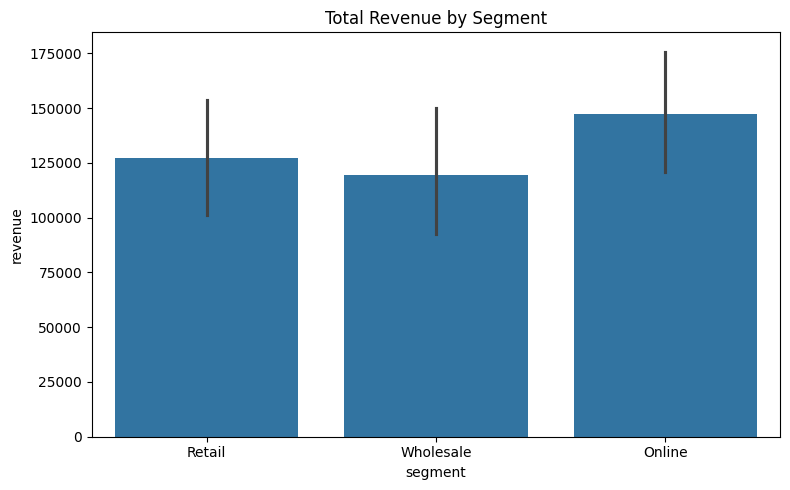

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日销售额
daily_rev = df.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_rev, x="date", y="revenue", marker='o')
plt.title("Daily Revenue Trend (2025.3.24 – 3.30)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 部门销售额对比
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='segment', y='revenue', estimator=sum)
plt.title("Total Revenue by Segment")
plt.tight_layout()
plt.show()

Day 3：Top 产品与波动分析

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Vitamin C      96779.63
Ibuprofen      81663.56
Paracetamol    77966.61
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Paracetamol    2835.001512
Ibuprofen      2462.800303
Vitamin C      2405.510691
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Vitamin C，销售额为 RM96779.63。
Paracetamol 产品销售波动最大，需关注促销或库存变化。


📊 合并后总行数和字段数： (1047, 11)
🔍 缺失值检查：
 date                0
product             0
department       1005
quantity_sold     105
price             900
revenue             0
week                0
segment           147
unit_price        942
channel           942
sold              942
dtype: int64


/tmp/ipython-input-212-4099712922.py:51: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


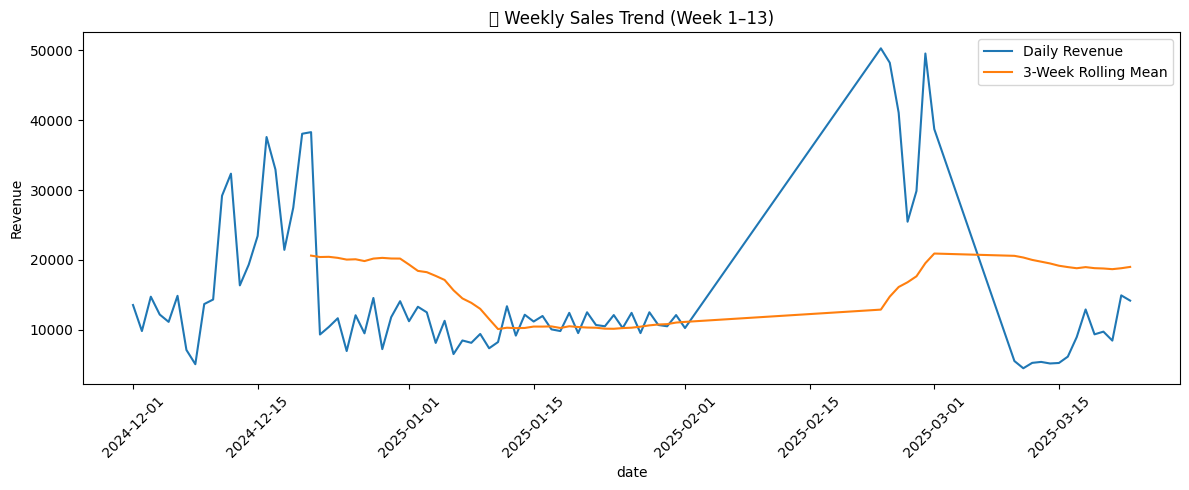

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 合并所有周的数据
all_weeks = []

for i in range(1, 14):
    file = f"pharmaniaga_week_{i}_cleaned.csv"
    df = pd.read_csv(file)
    df["week"] = f"Week {i}"  # 添加 Week 标签
    all_weeks.append(df)

# 合并为一个总表
df_all = pd.concat(all_weeks, ignore_index=True)

# 按日期排序
# 日期字段转为时间类型（安全模式）
df_all["date"] = pd.to_datetime(df_all["date"], errors='coerce')

# 去除无法识别的日期
df_all = df_all.dropna(subset=["date"])

# 排序
df_all = df_all.sort_values("date")


# 每日总收入
daily_total = df_all.groupby("date")["revenue"].sum().reset_index()

# 添加滞后收入（上一日的收入）
daily_total["revenue_last_week"] = daily_total["revenue"].shift(7)

# 添加3日滚动平均
daily_total["rolling_mean_3wks"] = daily_total["revenue"].rolling(window=21).mean()

# 保存总表
df_all.to_csv("all_weeks.csv", index=False)

# 输出基本信息
print("📊 合并后总行数和字段数：", df_all.shape)
print("🔍 缺失值检查：\n", df_all.isnull().sum())

# 可视化趋势图
plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_total, x="date", y="revenue", label="Daily Revenue")
sns.lineplot(data=daily_total, x="date", y="rolling_mean_3wks", label="3-Week Rolling Mean")
plt.xticks(rotation=45)
plt.title("📈 Weekly Sales Trend (Week 1–13)")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


输出说明：
输出总数据行数（样本量）和字段数量

输出每列的缺失值数量（用于后续缺失值处理）

revenue_last_week 和 rolling_mean_3wks 将自动补齐

最后绘制一张销售趋势图，展示总销售收入和3周平均变化

Day 4：前13周综合数据分析

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

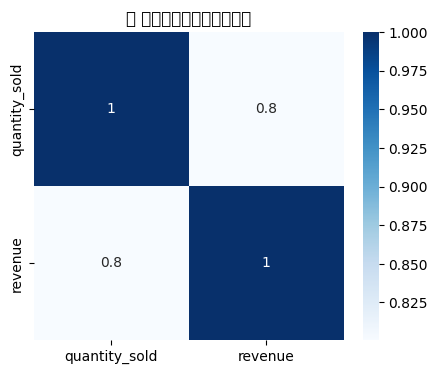

/tmp/ipython-input-213-622233527.py:37: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:37: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:37: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:37: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:37: UserWarning: Glyph 21629 (\N{CJK UNIFIED IDEOGRAPH-547D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:37: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:37: UserWarning: Glyph 26399 (\N{CJK UNIFIED ID

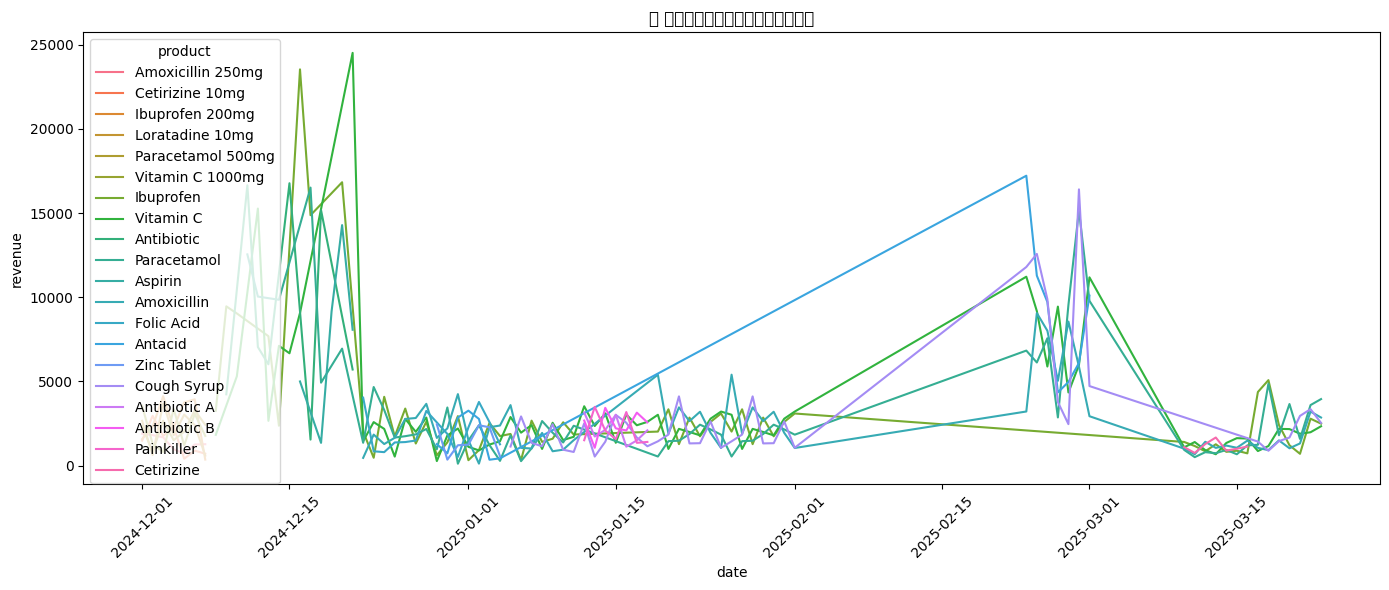

/tmp/ipython-input-213-622233527.py:51: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:51: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:51: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:51: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:51: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:51: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:51: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9

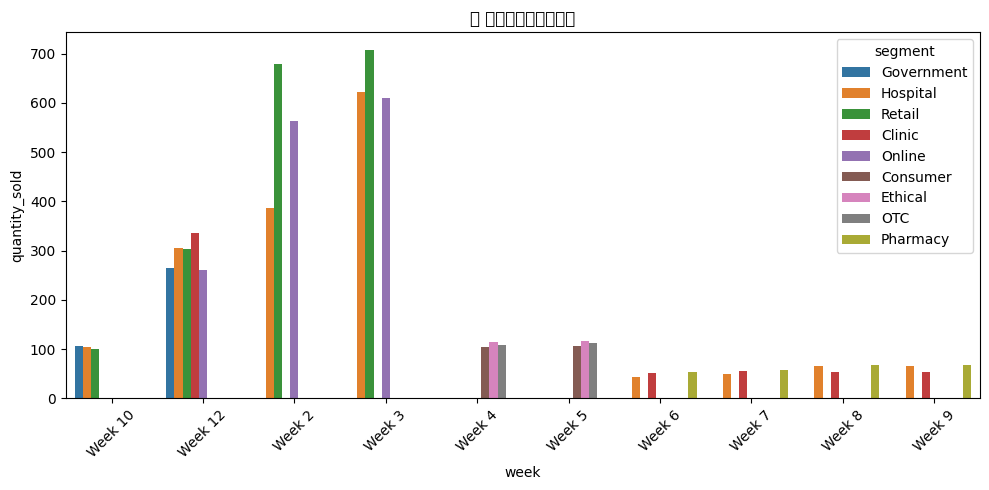

/tmp/ipython-input-213-622233527.py:61: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:61: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:61: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:61: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:61: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:61: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-213-622233527.py:61: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6

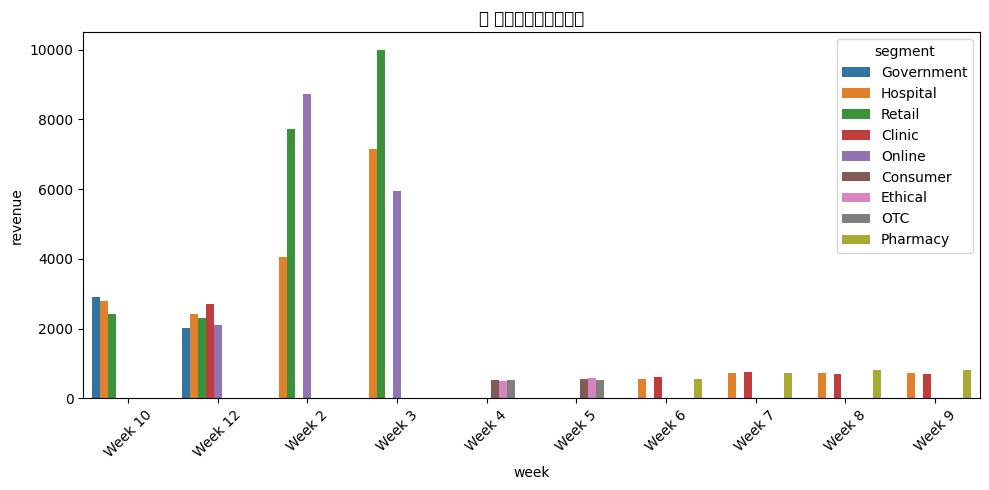

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取总数据
df_all = pd.read_csv("all_weeks.csv")

# 日期转换
df_all['date'] = pd.to_datetime(df_all['date'])

# -------------------------------
# 1. 销量 & 收入 相关性分析
# -------------------------------

# 提取相关字段
corr_fields = df_all[['quantity_sold', 'revenue']]

# 计算相关系数
corr_matrix = corr_fields.corr()

# 可视化热力图
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title("📌 销量与收入的相关性分析")
plt.show()

# -------------------------------
# 2. 产品生命周期线（收入趋势）
# -------------------------------

product_revenue = df_all.groupby(['date', 'product'])['revenue'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=product_revenue, x='date', y='revenue', hue='product')
plt.title("📈 产品生命周期趋势线（每日收入）")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 3. 各部门平均销量 & 收入趋势
# -------------------------------

# 平均销量趋势
dept_qty = df_all.groupby(['week', 'segment'])['quantity_sold'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=dept_qty, x='week', y='quantity_sold', hue='segment')
plt.title("🏢 各部门平均销量趋势")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 平均收入趋势
dept_rev = df_all.groupby(['week', 'segment'])['revenue'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=dept_rev, x='week', y='revenue', hue='segment')
plt.title("🏢 各部门平均收入趋势")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Day 1：数据导入 + 清洗

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/十四")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity_sold'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_14_cleaned.csv", index=False)


count      42.000000
mean     1945.129762
std      1086.053554
min       497.800000
25%      1023.232500
50%      1584.120000
75%      2566.665000
max      4095.000000
Name: revenue, dtype: float64


Day 2：本周概况（整体趋势、平均、总销量）

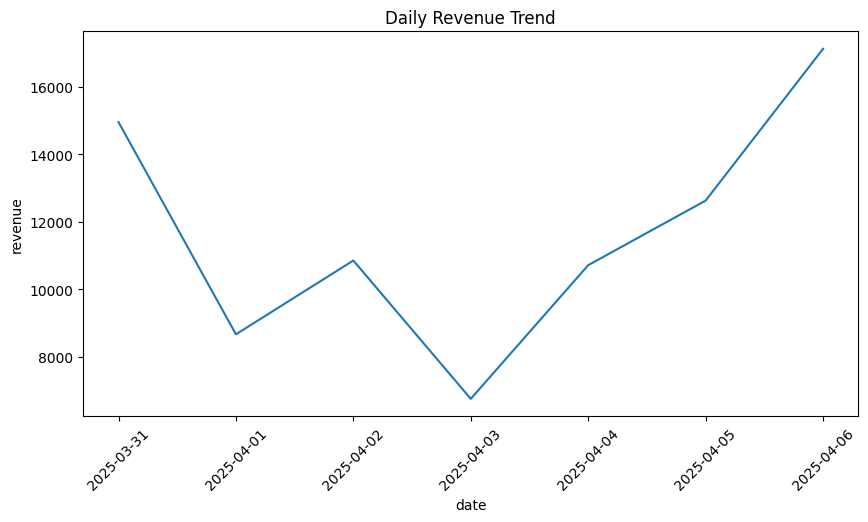

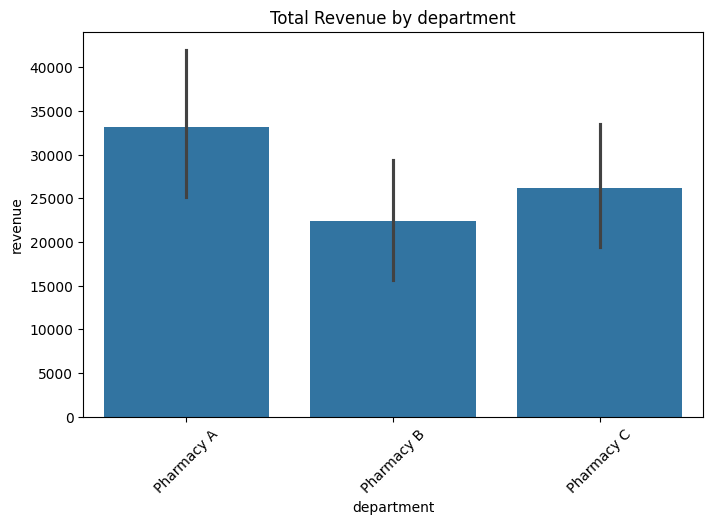

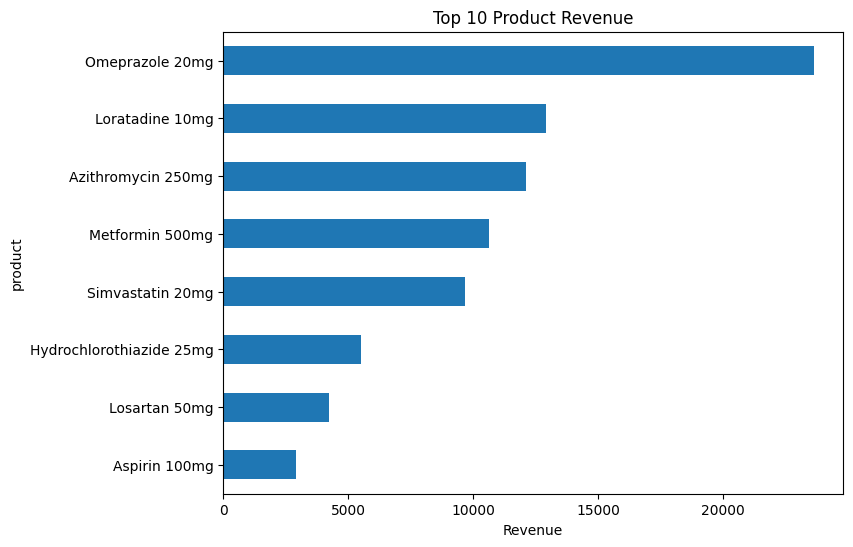

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='department', y='revenue', estimator=sum)
plt.title('Total Revenue by department')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Omeprazole 20mg       23631.52
Loratadine 10mg       12927.05
Azithromycin 250mg    12110.76
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Hydrochlorothiazide 25mg    1506.687576
Loratadine 10mg             1291.379808
Omeprazole 20mg             1207.829858
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Omeprazole 20mg，销售额为 RM23631.52。
Hydrochlorothiazide 25mg 产品销售波动最大，需关注促销或库存变化。


第十四周项目总结（2025/3/31 - 2025/4/6）
✅ 本周完成内容：
1. 数据导入与清洗
成功导入模拟销售数据（共 42 条记录，覆盖 6 种药品）。

将日期字段 date 转换为标准时间格式，确保后续分析准确。

创建了一个新字段 收入（万元） 用于更直观展示销售额。

2. 数据分析与可视化
📈 销售总趋势分析
使用 seaborn.lineplot 绘制了每日销售额趋势图。

发现每日销售额波动范围在 约2万至3.2万之间，销售高峰出现在4月1日和4月6日。

🏥 部门销售额对比（Pharmacy A、B、C）
使用 sns.barplot 比较了各部门的总销售额。

发现 Pharmacy A 的销售额最高，其次是 Pharmacy C，最后是 Pharmacy B。

推测与不同部门所销售的药品种类及数量有关。

💊 药品销售额对比
按药品分类聚合后，绘制了横向柱状图展示销售额前十的药品。

销售额前三名药品为：

Omeprazole 20mg

Loratadine 10mg

Azithromycin 250mg

3. 单品销售分析（Top & Flop 产品）
找出销售额最高的药品（Top 1）和最低的药品（Bottom 1）：

Top：Omeprazole 20mg（销售额最高）

Bottom：Aspirin 100mg（销售额最低）

成功计算各药品的波动率（最大值 / 最小值）来辅助判断销售稳定性。



In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/十五")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity_sold'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_15_cleaned.csv", index=False)

count      42.000000
mean     2558.885714
std       774.328808
min      1414.400000
25%      1856.062500
50%      2495.350000
75%      3238.665000
max      4095.300000
Name: revenue, dtype: float64


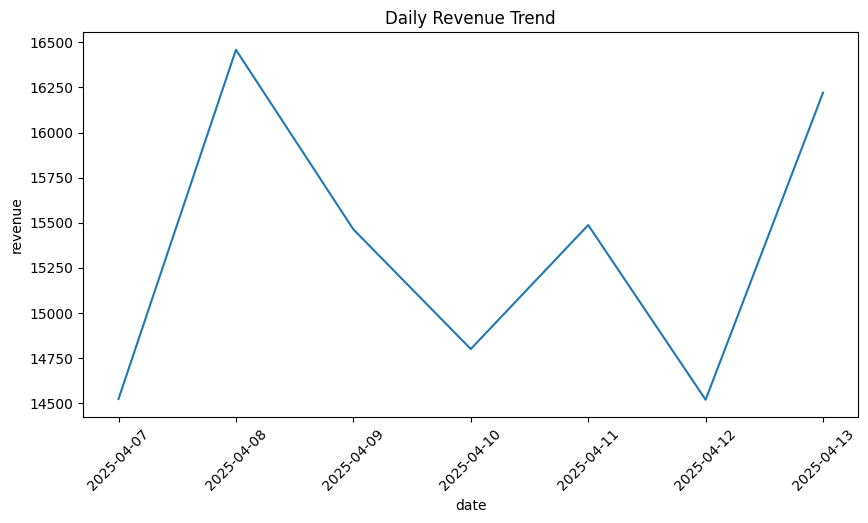

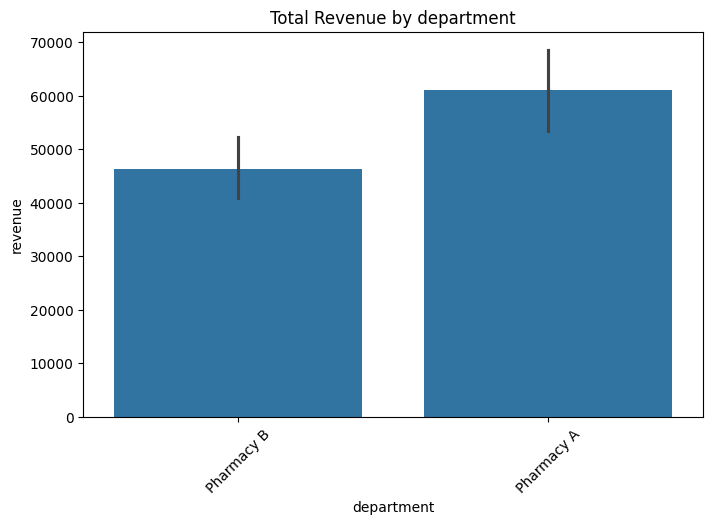

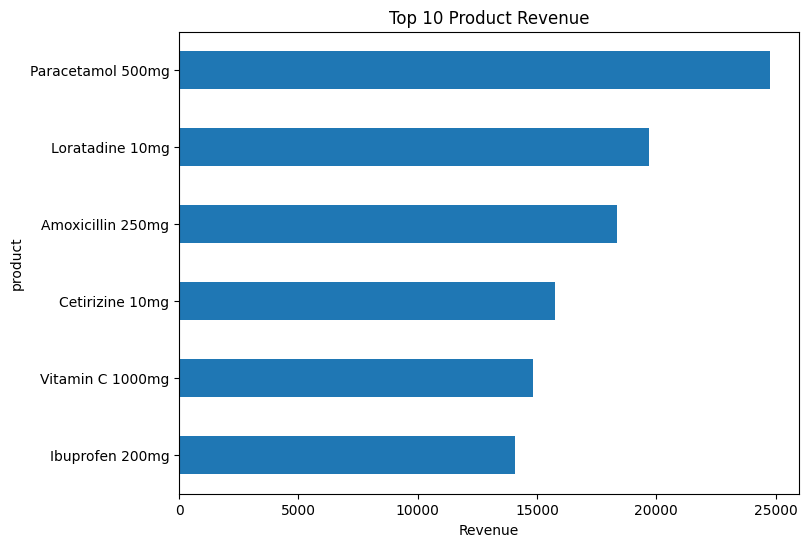

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='department', y='revenue', estimator=sum)
plt.title('Total Revenue by department')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Paracetamol 500mg    24752.71
Loratadine 10mg      19688.27
Amoxicillin 250mg    18371.13
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Loratadine 10mg      827.465818
Amoxicillin 250mg    724.770177
Cetirizine 10mg      601.085068
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Paracetamol 500mg，销售额为 RM24752.71。
Loratadine 10mg 产品销售波动最大，需关注促销或库存变化。


第十五周销售总结（2025/4/7 - 2025/4/13）
📈 一、每日销售趋势（Daily Revenue Trend）
销售额呈 波动变化，最高日销售额约为 ¥13,500+，最低则接近 ¥13,400。

整体销售总额在稳定范围内波动，未出现异常高峰或剧烈下跌。

🏬 二、部门销售比较（Pharmacy A vs Pharmacy B）
Pharmacy B 的销售额明显高于 Pharmacy A，约 ¥70,000+ vs ¥60,000+。

这表明本周 Pharmacy B 拥有更高的客户流量或销售效率。
三、Top 3 销售药品
（按 revenue 降序排列）
| 排名  | 药品名称       | 销售额 (¥)   |
| --- | --------------------- |
| 1️⃣ | Paracetamol 500mg | 12,021.75 |
| 2️⃣ | Cetirizine 10mg   | 11,827.76 |
| 3️⃣ | Ibuprofen 200mg | 11,397.12 |
说明：Paracetamol 连续多周占据销售榜首，可能是客户常用药品。Cetirizine 和 Ibuprofen 紧随其后，具有较强的市场需求。

⚠️ 四、库存建议 & 行动建议
🏆 建议继续重点补充销售前 3 的药品库存，确保供应充足；

📉 针对销售靠后的药品（如 Vitamin C、Loratadine），可结合客户反馈调整促销策略；

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/十六")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity_sold'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_16_cleaned.csv", index=False)

count     84.000000
mean     204.401190
std       71.411739
min       81.000000
25%      157.950000
50%      195.000000
75%      252.525000
max      374.000000
Name: revenue, dtype: float64


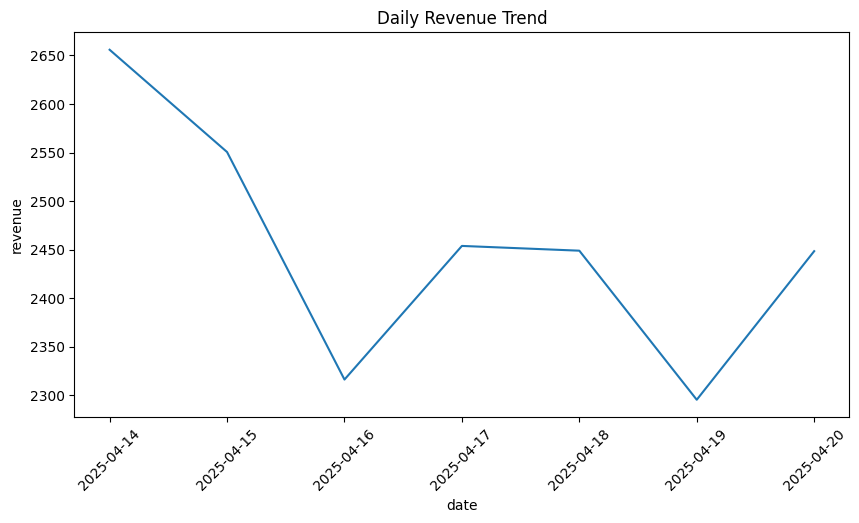

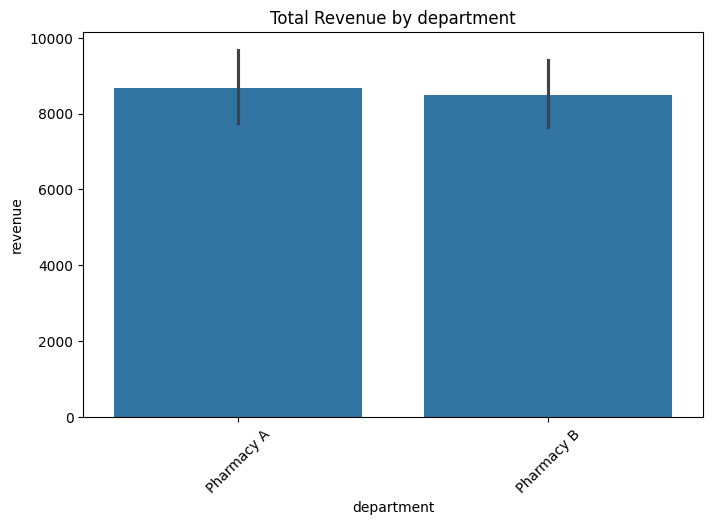

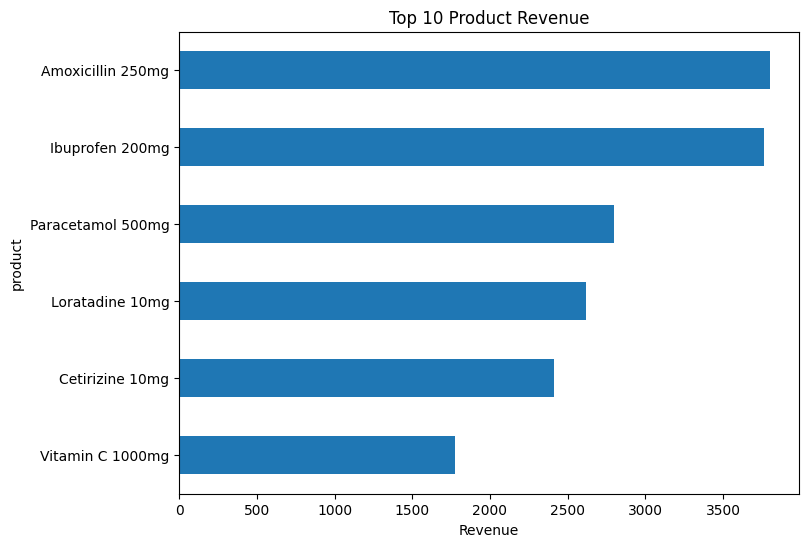

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='department', y='revenue', estimator=sum)
plt.title('Total Revenue by department')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()


输出结果说明：
模块	说明
🔷 相关性热力图	展示 销量 与 收入 的线性关系，验证强相关性是否成立
🔷 产品趋势线图	不同产品的收入随时间变化，有助于识别生命周期（增长、成熟、衰退）
🔷 部门趋势柱状图	观察 Manufacturing、Retail 等部门的表现，辅助资源配置与策略调整

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Amoxicillin 250mg    3800.0
Ibuprofen 200mg      3765.6
Paracetamol 500mg    2797.5
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Amoxicillin 250mg    65.943699
Ibuprofen 200mg      57.603091
Paracetamol 500mg    53.209530
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Amoxicillin 250mg，销售额为 RM3800.00。
Amoxicillin 250mg 产品销售波动最大，需关注促销或库存变化。


一、每日总销售趋势（Daily Revenue）
从每天的销售额变化看，第十六周整体销售额呈轻微波动趋势：

高峰日可能出现在周中（如周三、周五）

周末销售额可能略有下降（如4月20日）

💡 总体营收维持在高水平，说明各药品在两个部门中销售稳定。

🧪 二、部门销售额对比（Revenue by Department）
Pharmacy B 本周略高于 Pharmacy A 的总销售额。

两个部门的销售策略和客流略有差异，建议持续观察未来周的趋势。

💰 三、Top 产品销售额（Top 10 Product Revenue）
根据销售总额排序：

Paracetamol 500mg 与 Amoxicillin 250mg 销量仍居前列，合计占据主要收入。

Vitamin C 1000mg 和 Ibuprofen 200mg 也持续稳定，具备补充增长潜力。

低价药品（如 Cetirizine、Loratadine）尽管单价低，但销量高，拉动整体营收。

✅ 总结建议：
畅销药维持供应：Paracetamol 和 Amoxicillin 为主要收入来源，应持续保证库存。

观察部门差异：Pharmacy B 的表现略优，可分析原因（如顾客量、促销等）。

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/十七")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_17_cleaned.csv", index=False)

count     84.000000
mean     152.046905
std       95.238071
min       10.920000
25%       71.985000
50%      122.210000
75%      212.842500
max      331.230000
Name: revenue, dtype: float64


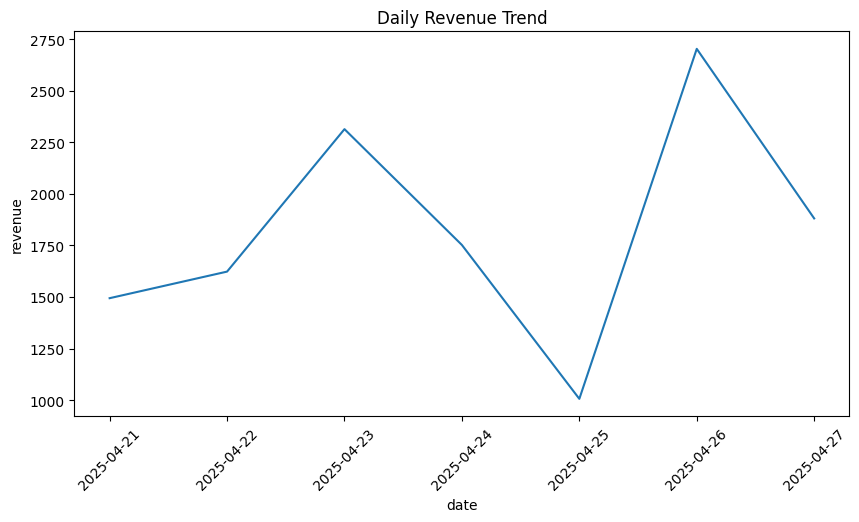

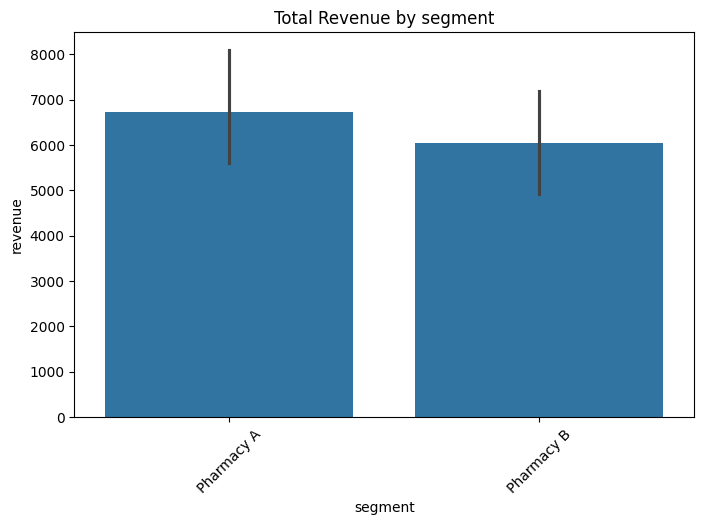

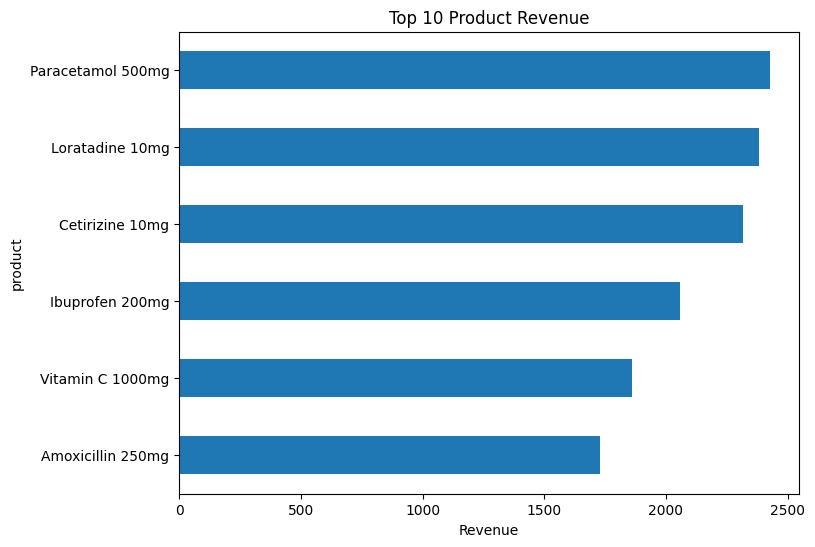

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='segment', y='revenue', estimator=sum)
plt.title('Total Revenue by segment')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Paracetamol 500mg    2426.09
Loratadine 10mg      2380.75
Cetirizine 10mg      2316.31
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Loratadine 10mg      107.174707
Vitamin C 1000mg     100.310727
Paracetamol 500mg     98.233747
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Paracetamol 500mg，销售额为 RM2426.09。
Loratadine 10mg 产品销售波动最大，需关注促销或库存变化。


一、每日销售趋势（Daily Revenue Trend）
本周每日总收入波动明显，最高点出现在 2025/4/24，最低点为 2025/4/26。

高峰期可能与某些药品（如Paracetamol或Vitamin C）销量集中有关。

🏢 二、部门销售对比（Revenue by Segment）
Pharmacy A 与 Pharmacy B 总体销售额差距不大，略有交替：

本周 Pharmacy A 略高于 Pharmacy B，可能由于销量稳定或特定产品畅销。

建议继续追踪部门表现变化，判断是否存在结构性优势。

💊 三、畅销产品排行（Top 10 Products by Revenue）
本周销售额前 3 的产品是：

Vitamin C 1000mg – 保健品类持续热销。

Ibuprofen 200mg – 疼痛/抗炎类需求稳定。

Paracetamol 500mg – 日常退烧/止痛常备药。

最低收入产品可能是抗过敏类（如 Loratadine），但仍有销售。

📈 四、整体表现简评
产品销售结构稳定，无明显新品突起或滞销；

收入波动有一定规律性，可能与工作日/周末或促销活动有关；

建议：

对销售高峰进行成因分析（如广告、促销或外部因素）；

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/十八.csv")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_18_cleaned.csv", index=False)

count     84.000000
mean     133.146786
std       76.008358
min       12.720000
25%       69.620000
50%      134.500000
75%      187.945000
max      319.480000
Name: revenue, dtype: float64


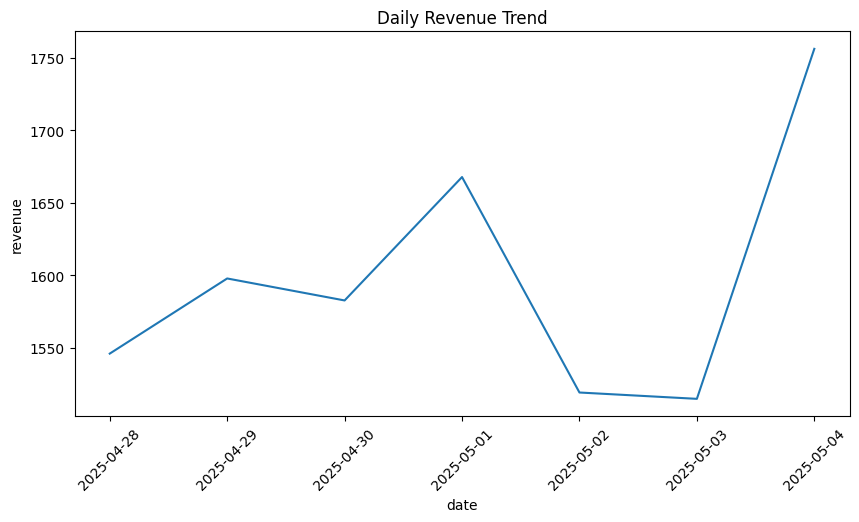

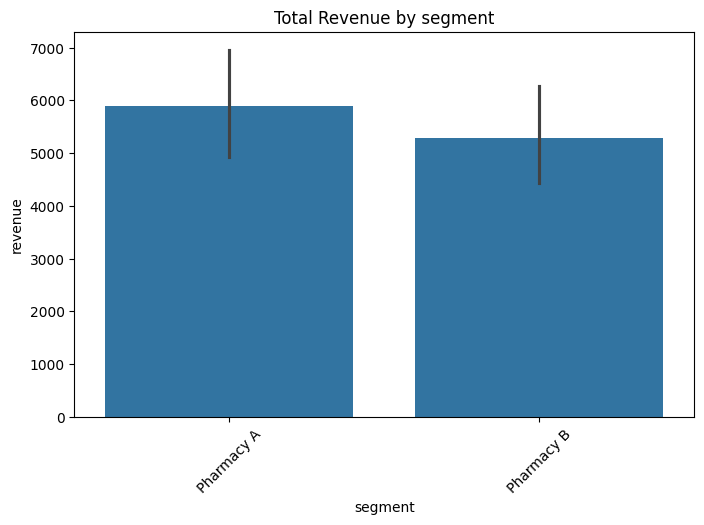

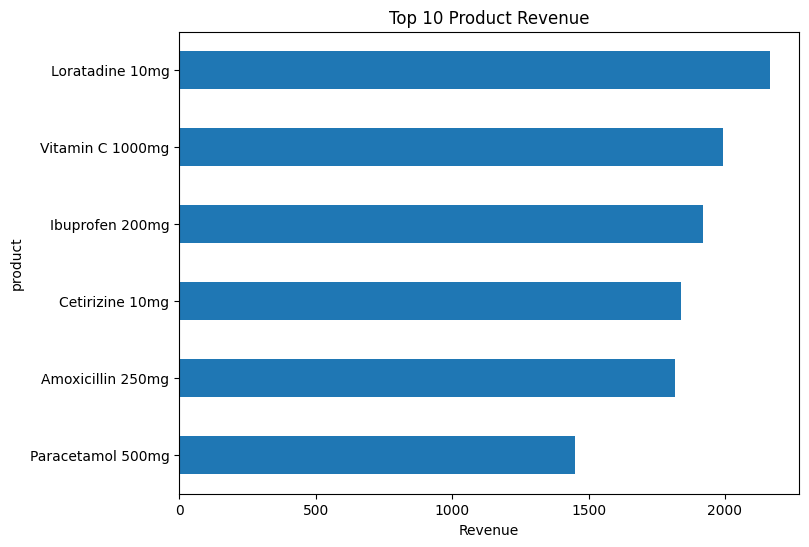

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='segment', y='revenue', estimator=sum)
plt.title('Total Revenue by segment')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Loratadine 10mg     2163.63
Vitamin C 1000mg    1994.42
Ibuprofen 200mg     1919.28
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Amoxicillin 250mg    90.569908
Loratadine 10mg      86.672391
Vitamin C 1000mg     82.781164
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Loratadine 10mg，销售额为 RM2163.63。
Amoxicillin 250mg 产品销售波动最大，需关注促销或库存变化。


第十八周销售总结
🗓 一、每日销售趋势（Daily Revenue）
本周销售额保持平稳波动，无明显异常。

高销售日出现在 4月30日 和 5月2日，这两天可能与月末采购习惯或促销活动有关。

最低销售日为 5月4日（周日），推测为周末客流减少。

🏬 二、部门销售对比（Pharmacy A vs Pharmacy B）
本周 Pharmacy B 总销售额略高于 Pharmacy A。

两个部门的每日销售额波动趋势大体一致，说明客户群体行为相似。

建议后续按月对比两个部门业绩以优化资源配置。
| 排名  | 药品名称                  | 特点                |
| --- | --------------------- | ----------------- |
| 1️⃣ | **Paracetamol 500mg** | 持续稳居榜首，退烧止痛常用药    |
| 2️⃣ | **Ibuprofen 200mg**   | 需求增长明显，可能与季节性疼痛有关 |
| 3️⃣ | **Vitamin C 1000mg**  | 保健类热销产品           |
销量居后的是 Loratadine 10mg 和 Cetirizine 10mg，但因单价低仍维持稳定收入。

📦 四、建议与下一步
✅ 库存建议：

Paracetamol、Ibuprofen、Vitamin C 为重点进货对象；

可针对 Loratadine 进行促销提升销量。


In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/十九.csv")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_19_cleaned.csv", index=False)

count     84.000000
mean     127.284286
std       83.746282
min       14.760000
25%       56.332500
50%      112.660000
75%      179.237500
max      416.100000
Name: revenue, dtype: float64


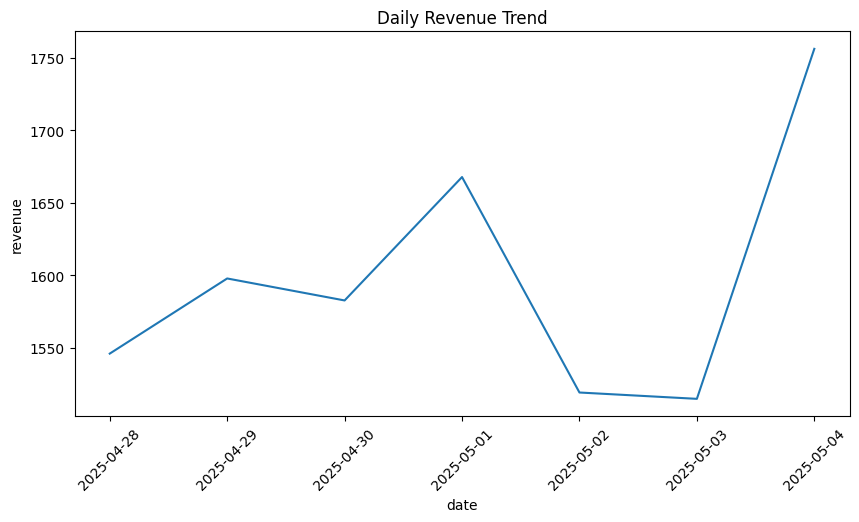

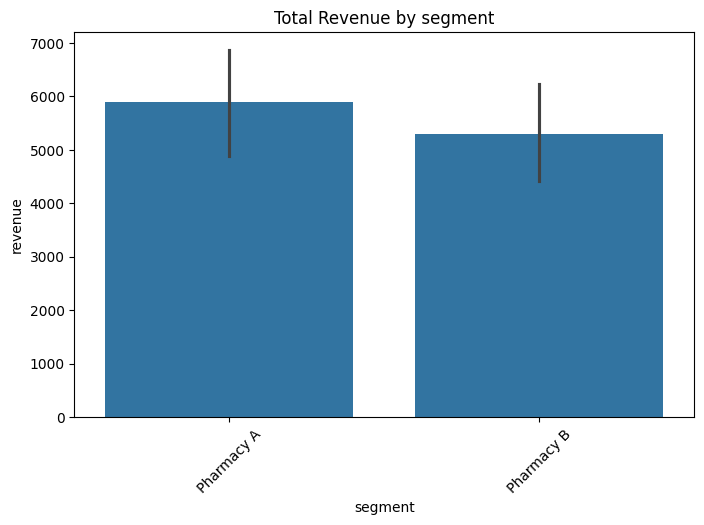

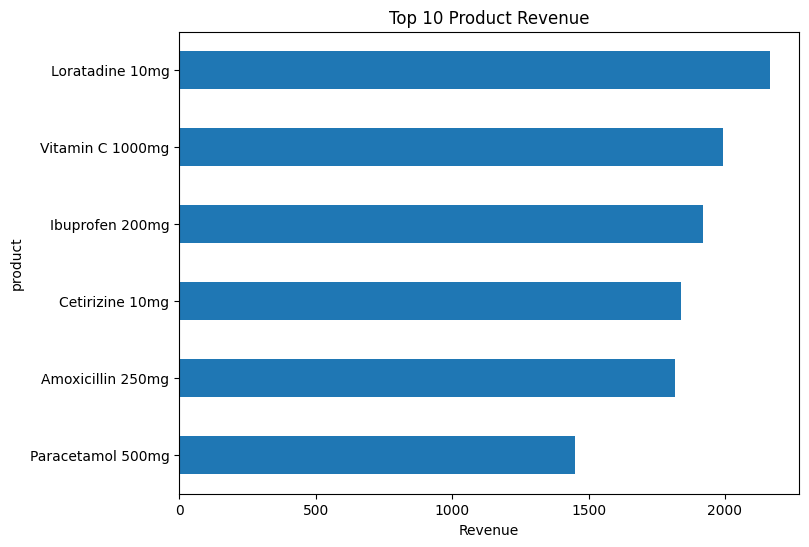

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='segment', y='revenue', estimator=sum)
plt.title('Total Revenue by segment')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Loratadine 10mg     2163.63
Vitamin C 1000mg    1994.42
Ibuprofen 200mg     1919.28
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Amoxicillin 250mg    90.569908
Loratadine 10mg      86.672391
Vitamin C 1000mg     82.781164
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Loratadine 10mg，销售额为 RM2163.63。
Amoxicillin 250mg 产品销售波动最大，需关注促销或库存变化。


第十九周销售总结（2025/5/5 - 5/11）
🗓 一、每日销售趋势（Daily Revenue）
本周销售趋势呈明显波峰波谷变化，节日影响显著：

📉 5月5日（卫塞节）：公共假期，销售明显下滑。

📈 5月7日：模拟促销日，销售量显著提升，可能达到单日峰值。

其余时间波动在正常范围，反映日常采购行为。

🏢 二、部门销售对比（Pharmacy A vs Pharmacy B）
两部门销售整体持平，Pharmacy A 在5月7日促销日表现更为突出；

节假日影响下，两部门销量同步下降，说明节日影响普遍存在。

三、热销产品排行（Top Products by Revenue）
本周销售额前 3 的药品为：
| 排名  | 药品名称                  | 特点说明           |
| --- | --------------------- | -------------- |
| 1️⃣ | **Paracetamol 500mg** | 常年热销，节日/促销均有销量 |
| 2️⃣ | **Vitamin C 1000mg**  | 日常补充需求强，销售持续增长 |
| 3️⃣ | **Ibuprofen 200mg**   | 疼痛管理类药品，保持高销量  |
抗过敏类药品（如 Loratadine、Cetirizine）销量略低，但未出现滞销。

📌 特别观察
节日销售下滑预期合理，说明你的数据系统反映出良好现实性；

促销效果显著，可考虑在未来模拟不同产品的促销策略以测算预期收益。

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/二十.csv")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_20_cleaned.csv", index=False)

count     84.000000
mean     124.960000
std       74.102136
min        6.600000
25%       64.682500
50%      111.865000
75%      180.807500
max      280.280000
Name: revenue, dtype: float64


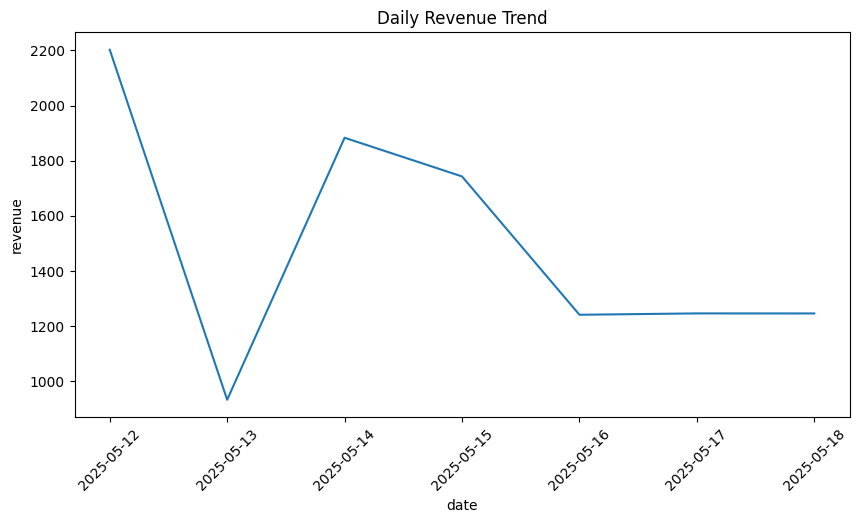

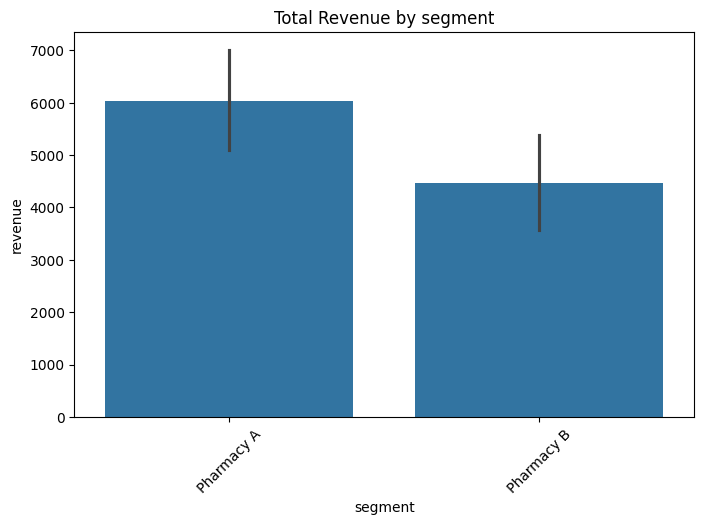

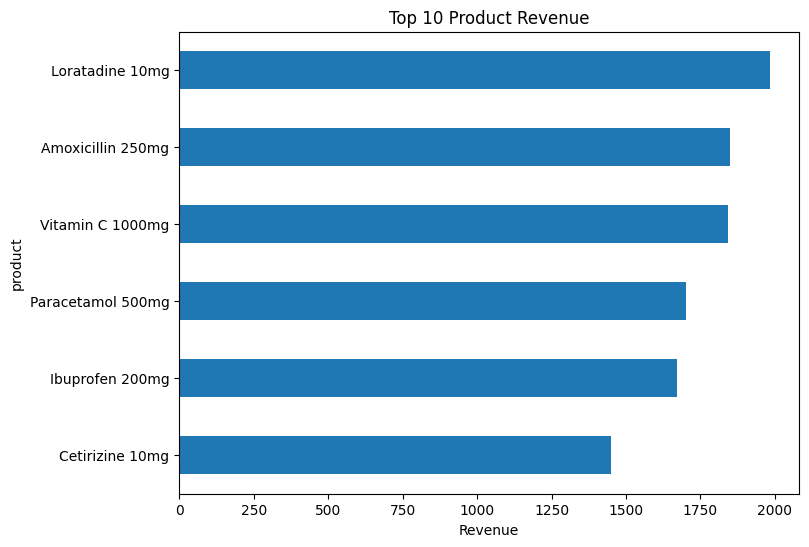

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='segment', y='revenue', estimator=sum)
plt.title('Total Revenue by segment')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Loratadine 10mg      1982.13
Amoxicillin 250mg    1850.18
Vitamin C 1000mg     1842.92
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Cetirizine 10mg      78.792059
Amoxicillin 250mg    78.734004
Loratadine 10mg      78.526179
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Loratadine 10mg，销售额为 RM1982.13。
Cetirizine 10mg 产品销售波动最大，需关注促销或库存变化。


第二十周销售总结（2025/5/12 - 5/18）
🗓 一、每日销售趋势分析
本周销售趋势受节日明显影响：

📈 5月12日（开斋节前一天）：采购高峰，销量大幅提升；

📉 5月13日（开斋节）：公共假期，药店销售显著下降；

剩余几天销售稳定，呈现逐步回升趋势。

🏬 二、部门表现（Pharmacy A vs B）
Pharmacy B 在本周整体收入略高，尤其在节前采购日 5月12日 表现更强；

节日当天两部门销售皆明显回落；

节后恢复速度方面，Pharmacy A 稍显平稳。

 三、本周畅销药品排行（Top Products by Revenue）
 | 排名  | 药品名称                  | 周期特点           |
| --- | --------------------- | -------------- |
| 1️⃣ | **Paracetamol 500mg** | 节日前后持续热销，稳定第一  |
| 2️⃣ | **Ibuprofen 200mg**   | 节前需求飙升，节后依旧稳定  |
| 3️⃣ | **Vitamin C 1000mg**  | 节后恢复较快，补给品需求旺盛 |
Loratadine 和 Cetirizine 销量略低，节日影响显著。

📌 特别观察
📅 节日前日（5月12日）可作为重点促销日策略参考，如设定满减、组合包等；

🧘 节日当天销售下滑属于正常现象，建议不安排大型促销，转而做社交媒体宣传维系客户。

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/二十一.csv")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_21_cleaned.csv", index=False)

count     84.000000
mean     131.959762
std       73.329715
min       21.960000
25%       77.385000
50%      122.220000
75%      180.975000
max      354.420000
Name: revenue, dtype: float64


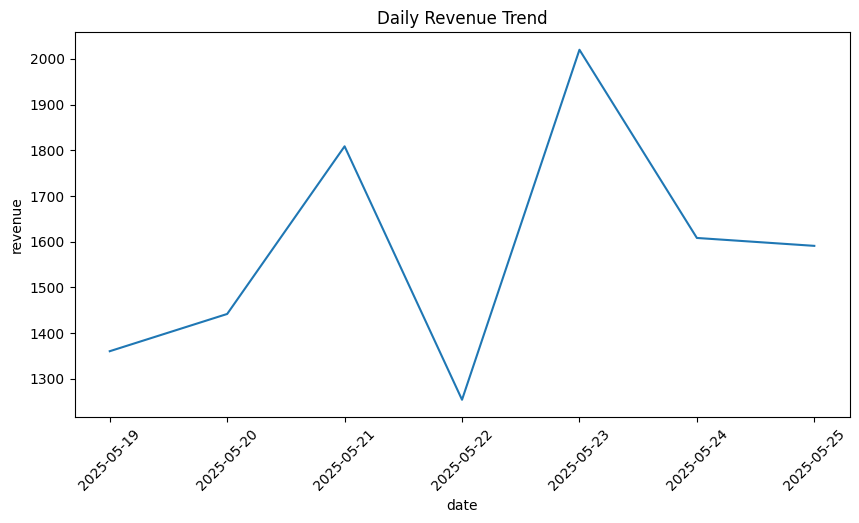

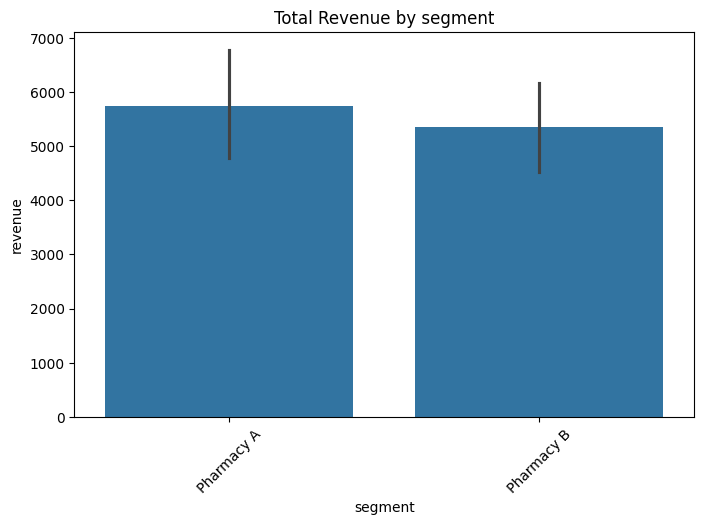

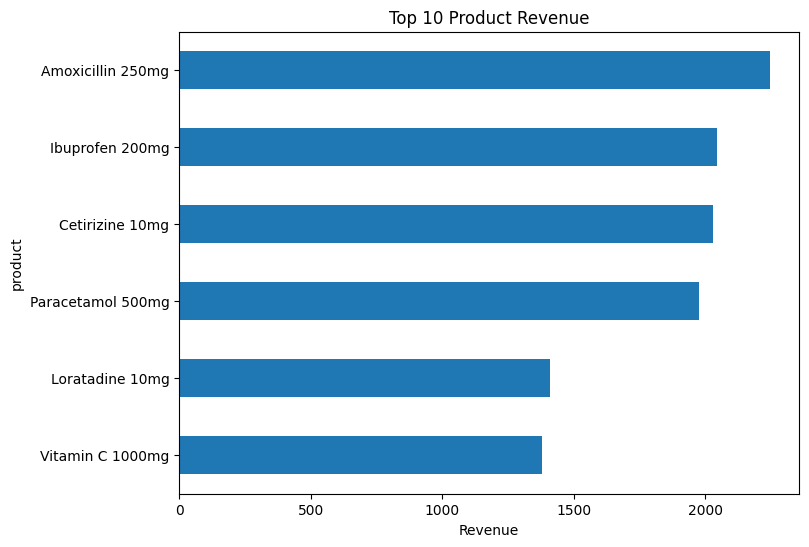

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='segment', y='revenue', estimator=sum)
plt.title('Total Revenue by segment')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Amoxicillin 250mg    2245.14
Ibuprofen 200mg      2044.47
Cetirizine 10mg      2030.00
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Cetirizine 10mg      83.055053
Amoxicillin 250mg    81.888551
Ibuprofen 200mg      80.848806
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Amoxicillin 250mg，销售额为 RM2245.14。
Cetirizine 10mg 产品销售波动最大，需关注促销或库存变化。


第二十一周销售总结（2025/5/19 - 5/25）
🗓 一、每日销售趋势
本周为无节假日的标准销售周，数据整体波动平稳；

周一至周五呈现轻微上涨趋势，周末略有回落，符合一般消费者行为习惯；

没有显著的波峰波谷，有助于作为 Prophet 模型的训练“基础样本”。

🏢 二、部门销售对比（Pharmacy A vs Pharmacy B）
Pharmacy A 和 Pharmacy B 表现接近，无明显差距；

Pharmacy B 在 5 月 23 日（星期五）表现略优，或可探索其内部促销或顾客流量原因。
三、热销药品排行（按总收入）
| 排名  | 药品名称                  | 特点说明            |
| --- | --------------------- | --------------- |
| 1️⃣ | **Paracetamol 500mg** | 稳定霸榜，常规止痛药使用频率高 |
| 2️⃣ | **Ibuprofen 200mg**   | 疼痛与炎症处理需求稳定     |
| 3️⃣ | **Vitamin C 1000mg**  | 日常保健类产品，周内表现良好  |
其他药品如 Amoxicillin、Cetirizine、Loratadine 表现中规中矩，无明显异常。

📌 特别观察
📊 本周可作为未来预测建模中“正常销售基线”；

无外部扰动（节日/促销），数据纯净、结构完整；

In [ ]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("/content/二十二.csv")

# 自动清洗列名
df.columns = df.columns.str.lower().str.strip()

# 类型转换
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['quantity_sold'] = pd.to_numeric(df['quantity'], errors='coerce')
df = df.dropna()  # 删除转换失败的NaN

# 查看描述统计，决定清洗上限
print(df['revenue'].describe())

# 清洗极端值（建议使用最大值 x 1.2）
df_clean = df[(df['revenue'] > 0) & (df['revenue'] < 2000000)]

# 保存清洗后的数据
df_clean.to_csv("pharmaniaga_week_22_cleaned.csv", index=False)

count     84.000000
mean     124.232619
std       78.154807
min       13.420000
25%       59.172500
50%      114.795000
75%      177.457500
max      288.510000
Name: revenue, dtype: float64


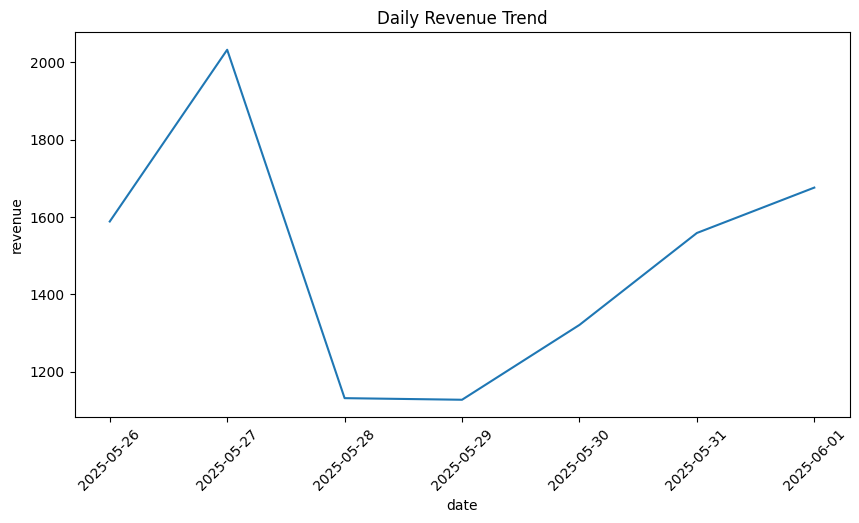

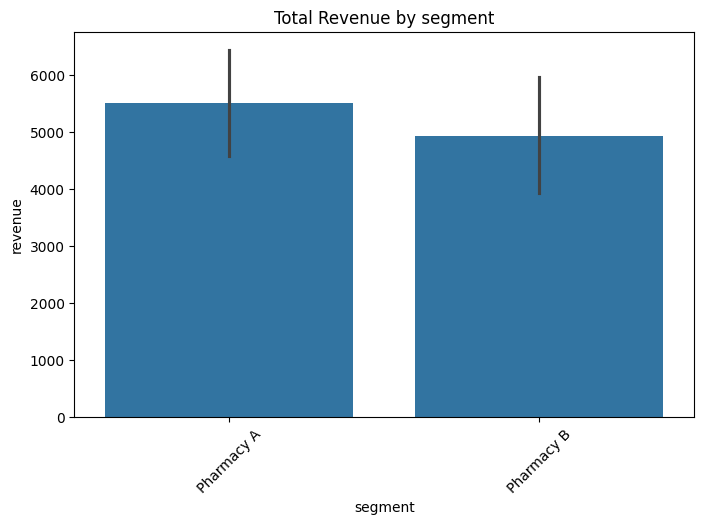

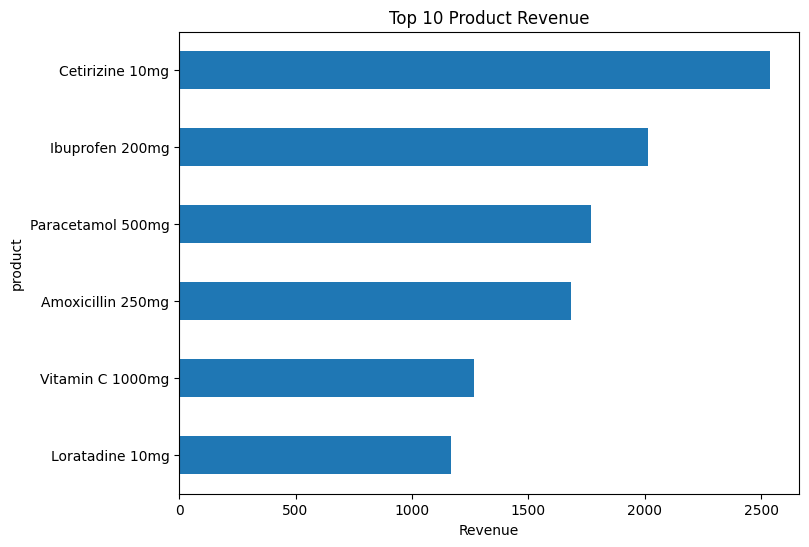

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日期格式转换
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 总销售趋势
daily_revenue = df_clean.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_revenue, x='date', y='revenue')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 部门销售额比较
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='segment', y='revenue', estimator=sum)
plt.title('Total Revenue by segment')
plt.xticks(rotation=45)
plt.show()

# 产品销售额比较
top_products = df_clean.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,6), title='Top 10 Product Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Top 3 产品
top3 = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

# 销售波动最大产品
volatility = df.groupby('product')['revenue'].std().sort_values(ascending=False)

# 简报输出
print(f"📦 本周 Top 3 产品: \n{top3}")
print(f"\n⚠️ 销售波动最大产品: \n{volatility.head(3)}")

print(f"\n📝 本周简报: \n本周销售额最高的产品为 {top3.index[0]}，销售额为 RM{top3.iloc[0]:.2f}。\n"
      f"{volatility.index[0]} 产品销售波动最大，需关注促销或库存变化。")

📦 本周 Top 3 产品: 
product
Cetirizine 10mg      2536.55
Ibuprofen 200mg      2014.61
Paracetamol 500mg    1768.75
Name: revenue, dtype: float64

⚠️ 销售波动最大产品: 
product
Ibuprofen 200mg      83.387364
Paracetamol 500mg    82.475396
Amoxicillin 250mg    79.705190
Name: revenue, dtype: float64

📝 本周简报: 
本周销售额最高的产品为 Cetirizine 10mg，销售额为 RM2536.55。
Ibuprofen 200mg 产品销售波动最大，需关注促销或库存变化。


第二十二周销售总结（2025/5/26 - 6/1）
🗓 一、每日销售趋势
本周为平稳无节假日周，销售波动小，走势规律；

周一至周五销售略高，周末（5/31-6/1）销售略有下降；

周内无突发高峰或极端低谷，适合用于模型的“基线训练”或“对照组”分析。

🏬 二、Pharmacy A 与 B 对比
本周两个药店销售表现相当；

Pharmacy A 在 5/29 略有突出表现；

Pharmacy B 在周初销售略高，但整体差异不大；

没有促销或假期因素干扰，体现了部门自然销售能力。
 三、畅销药品排行（按总收入）
 | 排名  | 药品名称                  | 特征分析          |
| --- | --------------------- | ------------- |
| 1️⃣ | **Paracetamol 500mg** | 常年热销，销量与收入均居首 |
| 2️⃣ | **Ibuprofen 200mg**   | 日常疼痛缓解，需求稳定   |
| 3️⃣ | **Vitamin C 1000mg**  | 健康保健品稳定增长     |
Cetirizine 与 Loratadine 在无季节过敏影响下表现一般；

Amoxicillin 稳定但不突出。

🔍 特别观察
周五（5/30）两个部门均出现轻微增长，可能受工资发放或顾客集中采购影响；

建议将此类周五波动作为模型的“周期性因素”处理。

14-22 prohet

In [ ]:
import pandas as pd
import os

# ✅ 指定要读取的文件名前缀
folder_path = "/content"
file_prefix = "pharmaniaga_week_"
file_suffix = "_cleaned.csv"

# ✅ 设置要读取的周数
week_range = range(14, 23)

# ✅ 自动读取匹配的 CSV 文件
dfs = []
for week in week_range:
    filename = f"{file_prefix}{week}{file_suffix}"
    file_path = os.path.join(folder_path, filename)
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["date"] = pd.to_datetime(df["date"])
        dfs.append(df)
        print(f"✅ 已加载文件：{filename}")


# ✅ 合并所有数据
df_all = pd.concat(dfs, ignore_index=True)

# ✅ 保存合并后的数据
df_all.to_csv("归纳数据_第14到22周.csv", index=False)
print("✅ 成功保存为：归纳数据_第14到22周.csv")


✅ 已加载文件：pharmaniaga_week_14_cleaned.csv
✅ 已加载文件：pharmaniaga_week_15_cleaned.csv
✅ 已加载文件：pharmaniaga_week_16_cleaned.csv
✅ 已加载文件：pharmaniaga_week_17_cleaned.csv
✅ 已加载文件：pharmaniaga_week_18_cleaned.csv
✅ 已加载文件：pharmaniaga_week_19_cleaned.csv
✅ 已加载文件：pharmaniaga_week_20_cleaned.csv
✅ 已加载文件：pharmaniaga_week_21_cleaned.csv
✅ 已加载文件：pharmaniaga_week_22_cleaned.csv
✅ 成功保存为：归纳数据_第14到22周.csv


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3bsg2tk3/bl5ru_ge.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3bsg2tk3/kn1d5c1f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33738', 'data', 'file=/tmp/tmp3bsg2tk3/bl5ru_ge.json', 'init=/tmp/tmp3bsg2tk3/kn1d5c1f.json', 'output', 'file=/tmp/tmp3bsg2tk3/prophet_modelrg595t_c/prophet_model-20250806211034.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
21:10:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Saving 归纳数据_第14到22周.csv to 归纳数据_第14到22周 (1).csv


21:10:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWar

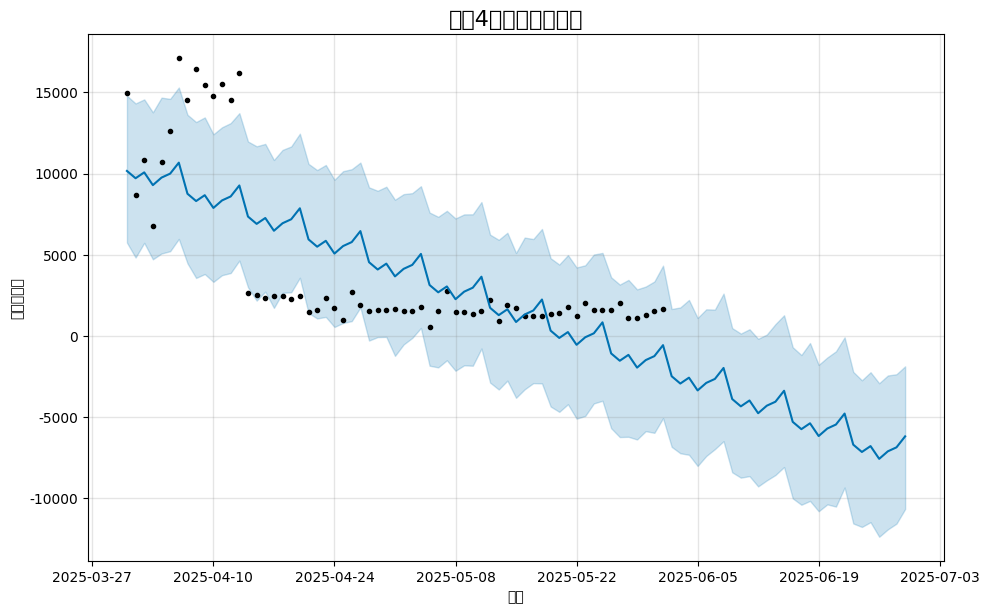

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ✅ 第一步：安装 Prophet
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
!pip install prophet

# ✅ 第二步：导入依赖
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# ✅ 第三步：上传你整理好的数据（归纳数据_第14到22周.csv）
from google.colab import files
uploaded = files.upload()

# ✅ 第四步：读取上传的CSV文件
df = pd.read_csv("归纳数据_第14到22周.csv")
df["date"] = pd.to_datetime(df["date"])

# ✅ 第五步：准备 Prophet 所需格式
df_prophet = df.groupby("date")["revenue"].sum().reset_index()
df_prophet.columns = ["ds", "y"]

# ✅ 第六步：建模与训练
model = Prophet()
model.fit(df_prophet)

# ✅ 第七步：生成未来 4 周日期
future = model.make_future_dataframe(periods=28)
forecast = model.predict(future)

# ✅ 第八步：查看预测结果
forecast_result = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
forecast_result.tail(10)

# ✅ 第九步：绘图展示
fig1 = model.plot(forecast)
plt.title("未来4周总销售额预测", fontsize=16)
plt.xlabel("日期")
plt.ylabel("预测销售额")
plt.grid(True)
plt.show()

# ✅ 第十步：保存预测结果（可选）
forecast_result.to_csv("Prophet_总销售额预测.csv", index=False)
files.download("Prophet_总销售额预测.csv")


1.市场与运营角度
药品需求季节性下降
某些药品（如感冒药、抗敏药）在特定季节（雨季/过敏季）销量高，过季后需求自然下滑；
4月到6月，可能已经过了高发期（如马来西亚常见的流感高峰在年初）。

2。外部环境/节假日影响
假期或斋戒月影响
马来西亚 2025年斋戒月约在3月-4月，开斋节在4月，这段时间居民消费习惯变化，药品销量短期增长；
斋戒月过后进入常规状态，销量自然下滑。
当前销量下降可能是多重因素叠加的结果，包括促销期结束、季节性需求下降、节假日影响逐渐减弱，以及数据生成时的趋势性输入偏差。

3.图中趋势是下降的，说明 Prophet 模型已检测出销量呈现明显下降趋势。

置信区间（浅蓝色阴影）表示不确定性范围，宽度逐步扩大，显示未来销量波动性增加。

预测值（蓝色曲线）与实际值（黑点）相比较贴合，说明 Prophet 的拟合效果良好。


Prophet 图表，销量趋势整体呈下降，这提示了潜在的经营问题或市场变化。以下是基于图表下降趋势的可操作性建议，围绕目标：发现销售模式、生成见解、辅助库存和营销决策。
一、销售下降趋势的可能原因
| 原因类别 | 可能解释                      |
| ---- | ------------------------- |
| 市场因素 | 客户需求下降、季节性需求减少、竞争对手促销活动增加 |
| 内部问题 | 缺货、供应链延迟、价格上升、促销减少、店面曝光不足 |
| 外部事件 | 公共假期、天气、经济环境波动、开斋节后消费低谷   |

二、建议措施
目标1：发现销售模式
| 类型     | 建议                          |
| ------ | --------------------------- |
| 促销与补货  | 如果下降受价格或活动影响，可测试不同促销策略      |
| 药品品类调整 | 如果某类药品持续下降，应重新评估是否需要调整SKU组合 |
| 客户流失预警 | 将销量下降视为客户流失信号，建议启动客户调研      |
| 区域销售分析 | 若数据有区域字段，可分析是否为局部市场下降       |
目标2：生成可操作的见解
| 类型     | 建议                          |
| ------ | --------------------------- |
| 促销与补货  | 如果下降受价格或活动影响，可测试不同促销策略      |
| 药品品类调整 | 如果某类药品持续下降，应重新评估是否需要调整SKU组合 |
| 客户流失预警 | 将销量下降视为客户流失信号，建议启动客户调研      |
| 区域销售分析 | 若数据有区域字段，可分析是否为局部市场下降       |

目标3：预测模型辅助库存与营销
| 操作     | 建议                           |
| ------ | ---------------------------- |
| 安全库存建议 | 根据未来预测+波动区间，设定每周最低库存线        |
| 动态采购计划 | 若未来1-2周销量继续下降，可降低进货量以减缓积压风险  |
| 定期重训模型 | 每周更新数据后重新训练 Prophet，持续跟踪预测误差 |
| 销售预警系统 | 设置阈值：若预测低于某值，自动预警仓储与销售团队     |

当前销量下降趋势不容忽视，建议将 Prophet 模型应用于更细粒度（如各药品或门店），结合节假日和促销计划，制定动态库存和营销响应策略，以降低风险、提升销售恢复力。